# Evaluating glacier response to lake level perturbations: idealized experiments with application to Lunana, Bhutan

Chris Miele¹, Faezeh Nick¹, Walter Immerzeel¹

¹*Department of Physical Geography, Utrecht University*

*Corresponding author: Chris Miele (`c.m.bezu@uu.edu`)*

> **About this notebook.** This is an executable version of the manuscript prepared for *Geophysical Research Letters*. The prose cells mirror the paper; the code cells reproduce the experiments described in the Methods. The two experiment sets are run in order: an idealized flowline (Section 3.1, fully self-contained) and an observation-informed model of Luggye Glacier (Section 3.2, whose bed inversion reads cluster-local data — paths are parameterised in the inversion cell). The notebook is meant to be run top to bottom; later cells depend on the model machinery defined below.

**Key Points**

- Point number one
- Point number two
- Point number three

## Abstract

Proglacial lakes across the Himalaya are expanding rapidly in both area and number, altering glacier dynamics and heightening the risk of glacier lake outburst floods (GLOFs). Yet how individual glaciers respond dynamically to changes in lake level remains poorly constrained. Here, we first construct an idealized flowline model to examine how a lake-terminating glacier responds to lake-level perturbations under different sliding and calving laws. We then repeat similar experiments using the observed geometry of Luggye Glacier, a lake-terminating glacier in the Lunana region of Bhutan. Across different choices of basal friction law and calving law, we find that an increase in lake level universally results in near-terminus thinning and speedup, alongside an increase in calving flux. Conversely, decreases in lake level tend to produce slowdown and reduce calving flux. We conclude that even modest lake-level rises may increase GLOF risk by driving terminus acceleration and further mass delivery into the lake. However, even a modest artificial reduction of proglacial lake levels may constitute an effective GLOF risk mitigation technique.

## Plain Language Summary

Glaciers that end in lakes are retreating faster than their land-terminating counterparts, and across the Himalaya these proglacial lakes are growing — raising the risk of catastrophic floods for communities downstream. Using a numerical ice flow model, we tested how glaciers respond to small rises and drops in lake level. We find that even modest lake-level rises cause a glacier to speed up and shed more ice into the lake, while lake-level drops tend to slow the glacier down, reducing ice delivery into the lake. This suggests that engineering projects designed to reduce proglacial lake level may be an effective risk mitigation technique.

## 1 Introduction

Mountain glaciers have lost mass at an accelerating rate over recent decades (Hugonnet et al., 2021), while proglacial lakes have expanded simultaneously in number, area, and volume (Shugar et al., 2020). Both of these global trends are apparent across the Himalaya (Ahmed et al., 2021; Zhang et al., 2023), where the presence of proglacial lakes is associated with thinning, speedup, and retreat substantially above the regional mean (King et al., 2018). Many proglacial lakes, in addition to fundamentally altering dynamics at the terminal boundaries of glaciers, also pose an acute hazard by way of glacial lake outburst floods (GLOFs). GLOFs have caused widespread destruction and loss of life both globally and across the Himalaya (Taylor et al., 2023; Nie et al., 2018). For high-risk communities, better understanding the interplay between proglacial lake evolution and glacier dynamics is an immediate and high-priority concern (Wangchuk & Tsubaki, 2024; Mir et al., 2025).

The presence of a proglacial lake modifies glacier behaviour in three fundamental ways. First, proglacial water exerts compressive backpressure against the ice face, reducing extensional stress at the front (e.g., Cuffey & Paterson, 2010; van der Veen, 2013). Second, water pressure reduces the effective overburden pressure of the ice, consequently — though depending on the sliding law — reducing basal friction, thereby increasing extensional stresses near the front (Truffer et al., 2001; Tsai et al., 2015). Third, any proglacial water body introduces frontal mass loss processes absent at land-terminating glaciers, providing a mechanism for rapid retreat and enhancing mass wastage into the lake (Watson et al., 2020).

How these processes interact is not straightforward, and a glacier's net response to changing lake levels likely depends on the nature of the calving laws and sliding laws simultaneously at work. For instance, power-law sliding relations (Weertman, 1957) typically carry no dependence on water pressure, so a rising lake affects a glacier only through the first and third mechanisms above. In contrast, sliding laws invoking Coulomb failure (Tsai et al., 2015) allow basal resistance to decrease as a glacier's front approaches flotation. In this case, a rising lake level introduces competition between the increased backpressure against the terminus, which slows a glacier down, and the decreased basal resistance, which speeds it up. The calving law introduces a further level of complexity: two calving laws, even if framed in terms of the same underlying forcing, can produce fundamentally different terminus responses. Under a rate-based law, calving competes with ice velocity: a sufficiently fast-flowing glacier can maintain a steady terminus position even under strong calving forcing, with the two in dynamic balance. Under a position-based law, the terminus is placed directly by the calving criterion, and no amount of forward flux can sustain a position beyond the prescribed threshold. In either case, since the calving law determines the location — and thereby the ice thickness and water depth — at the frontal boundary, the system is internally coupled in a way that makes the net response to a lake-level change difficult to predict without numerical modeling.

In this paper, we use the ice dynamics package icepack (Shapero et al., 2021) to systematically investigate the dynamic response of glaciers to lake-level perturbations, with attention to how the response varies depending on the types of sliding laws and calving laws used. We perform experiments in an idealized setting, as well as on an observation-informed flowline model of Luggye Glacier, a lake-terminating glacier in Lunana, Bhutan.

### 1.1 Luggye Glacier

The Lunana region of northern Bhutan is home to four large lake-terminating glaciers — Luggye, Thorthormi, Raphstreng, and Bechung. At least 18 GLOFs have been recorded across Bhutan since the 1950s (Rinzin et al., 2023), and the Lunana complex has been the site of some of the most destructive. The most serious was the partial breach of Luggye Tsho, the proglacial lake at the terminus of Luggye Glacier, in October 1994. Floodwaters and debris surged approximately 90 km downstream, killing 21 people and causing extensive damage to cropland and infrastructure (Watanabe & Rothacher, 1996; Maurer et al., 2020). The lake has expanded continuously since at least the 1970s, driven by (and likely driving) ongoing glacier retreat, and continues to grow (Maurer et al., 2020). In response to the regional hazard, engineered interventions have been undertaken to lower lake levels, most notably a project targeting Thorthormi Tsho that succeeded in lowering its water level by approximately 5 m, though the lake remains dangerous (Rinzin et al., 2023). Luggye Tsho is currently assessed as among the most susceptible lakes in the Lunana complex to future GLOFs (Rinzin et al., 2023), making Luggye Glacier a natural focus for process-based modelling of glacier-lake dynamics.

## 2 Model and methods

We systematically investigate how the dynamic response of lake-terminating glaciers to lake-level perturbations depends on the choice of sliding law and calving law, using the ice dynamics package icepack (Shapero et al., 2021). We conduct two sets of numerical experiments: the first uses an idealized flowline geometry; the second uses an observation-informed flowline representation of Luggye Glacier. In each case, we obtain a reference glacier geometry for each (sliding law, calving law) pair (see Section 2.4 for details). We then induce a series of perturbations to the lake level, applied as a linear ramp from zero to a target offset over a prescribed ramp time and then held at the target for a prescribed hold time; setting the ramp time to zero recovers an instantaneous step. The perturbation range, increment, and ramp/hold durations are exposed as user controls at the top of the notebook. At the end of each experiment we record four diagnostics, each relative to the corresponding zero-perturbation baseline: the change in terminus position, the change in terminus speed, the change in grounding-line flux (expressed as a mean rate over the experiment), and the change in ice thickness at a common upstream reference location (defined in Section 3 as the most upstream terminus position attained across all experiments in the set, providing a single x at which every configuration still has ice). The subsections below describe the model physics, sliding laws, calving laws, and initial configurations.

### 2.1 Ice flow approximation

Glacier flow is commonly approximated using either the Shallow Ice Approximation (SIA) (Hutter, 1983), in which flow is primarily resisted by basal drag, or the Shallow Shelf Approximation (SSA) (Morland, 1987; MacAyeal, 1989), in which longitudinal stress gradients dominate. For a lake-terminating glacier, neither alone is sufficient: basal drag likely dominates upstream, but it may decrease substantially if the terminus advances into deep water. We therefore use the Higher Order (HO) Approximation (Blatter, 1995), which captures both regimes and is appropriate across the range of conditions our experiments explore.

### 2.2 Sliding laws

Sliding laws can be categorized between two end-member forms. In pure power-law relations (Weertman, 1957), the basal shear stress $\tau_b$ depends only on the basal sliding velocity $u_b$, with no sensitivity to basal water pressure. This produces a relationship of the form

$$\tau_b = C\,|u_b|^{1/m}, \tag{1}$$

where $C$ and $m$ are constants. This is the first sliding law considered in our analysis. In contrast, in pure Coulomb laws (e.g., Truffer et al., 2001; Tsai et al., 2015), $\tau_b$ depends only on the effective pressure at the bed, so that basal resistance collapses to zero as ice approaches flotation. As our second sliding law, we implement an intermediate relation which retains the form of Equation 1 but includes effective pressure dependence:

$$\tau_b = C\,f_{af}\,|u_b|^{1/m}. \tag{2}$$

Here, $0 \le f_{af} \le 1$ is the clamped fraction above flotation. Where $f_{af} = 0$, the basal shear vanishes, as in a Coulomb law; and where $f_{af} = 1$, Equation 2 reduces to the power-law relation of Equation 1. Relations of this form are well-established, if somewhat ad hoc (e.g., Budd et al., 1979, 1984; Pattyn, 2002), and the formulation has a useful property for our purposes: the two laws are identical where ice is well-grounded, and they diverge only as the terminus approaches flotation. The effect of the sliding law choice is, therefore, concentrated precisely where lake-level changes act.

> *Implementation note.* In the code these are the `power_law` (Eq 1) and `effective_pressure` (Eq 2) sliding laws. Both share the friction coefficient `C`; `effective_pressure` multiplies it by the fraction above flotation $f_{af}$ (clamped to $[0.01, 1]$ for numerical stability), so the two coincide where ice is well grounded and diverge only near the terminus.

### 2.3 Calving laws

Before describing the calving laws, we clarify the distinction between calving flux and mass delivery to the lake. For a grounded terminus, the two are equivalent: every calved volume contributes mass into the lake directly. For a glacier with a floating tongue, however, calving from the floating face removes ice that is already afloat and does not constitute true ice discharge. In this case, there has been calving flux but no grounding-line flux. We therefore distinguish the two conceptually and report grounding-line flux as the physically meaningful measure of mass delivery to the lake; calving modulates that delivery only when it results in a grounded terminus.

Likewise, calving laws can be separated conceptually into two categories: rate laws, which prescribe a length change per unit time, and position laws, which prescribe a calving front location at a given time (Amaral et al., 2020). Because it is usually possible to observe terminus retreat only from above the waterline, we make no attempt to independently parameterize submarine melt. Thus, the "calving laws" discussed in this section implicitly describe the combination of mechanical calving and subaqueous melt.

We first consider a depth-based rate law:

$$\dot{L} = k\,d, \tag{3}$$

with $\dot{L}$ the rate of glacier length change, $k$ a scaling factor, and $d$ the water depth at the grounding line. This constitutes a simplified version of the minimal calving law described by Oerlemans and Nick (2005), where we have divided the original formulation by frontal area to express the result in terms of length change, rather than calving flux. This calving law is used, for example, in the Open Global Glacier Model, OGGM (Recinos et al., 2019). While this calving law is more typically given in terms of the terminus water depth, we have generalized to water depth at the grounding line on the basis that (1) the two are equivalent when the terminus is grounded, and (2) when a floating tongue is present, the grounding line depth better characterizes the water depth actually encountered by the glacier.

We also consider a simple position law, which sets the glacier length, $L$, to

$$L = \max\{x : f_{af} \geq f^*\}, \tag{4}$$

where $f^*$ is a tunable fraction-above-flotation threshold. That is, the front of the glacier retreats to the most downstream point at which it attains the prescribed degree of grounding (Vieli et al., 2001). We note that the use of the non-strict inequality in Equation 4 is deliberate: since a floating terminus has $f_{af} = 0$, a strict inequality would prevent the formation of a floating tongue for nonnegative $f^*$. The non-strict inequality ensures that the position law here is general enough to permit any floating configurations that may emerge under other calving laws.

Both the position law and the rate law are ultimately governed by the same variable — water depth, which controls both $d$ in Equation 3 and $f_{af}$ in Equation 4 — allowing us to better isolate the effect of the rate vs. position formulation rather than the choice of underlying forcing.

Finally, we also describe the trivial calving law,

$$\dot{L} = 0. \tag{5}$$

We include this third calving law for two reasons. First, it is so commonly applied that it warrants inclusion for completeness: Equation 5 requires that forward velocity be exactly balanced by frontal ablation, and it is implicitly used in any ice sheet or glacier model that does not include a mechanism for advance or retreat. Second, and more specifically to our experimental design, the trivial calving law has no free parameters, making it the natural choice for spinning up the reference configurations from which the rate and position laws are calibrated (Section 2.4).

> *Implementation note.* In the code these are `depth_rate` (Eq 3), `flotation` (Eq 4), and `trivial` (Eq 5). Equation 4 uses the non-strict inequality $f_{af} \geq f^*$ deliberately: since a floating terminus has $f_{af} = 0$ exactly, a strict inequality would prevent $f^* = 0$ from ever being satisfied at a floating face, forcing the front back to the grounding line regardless of the reference geometry. The non-strict form instead lets $f^* = 0$ represent a terminus that has reached, but not exceeded, flotation; when $f^*$ calibrates to (effectively) zero, the code takes a direct unconstrained-advance shortcut rather than searching for it every step. The position law is evaluated as a pure function of the current state: the front is placed at the most-inland point of the contiguous near-flotation zone that touches the terminus, with sub-grid linear interpolation of the $f_{af} = f^*$ crossing. Independently of the active calving law, every step also locates the grounding line itself (the most-downstream point with $f_{af}$ strictly positive) and reports the ice flux crossing it as `grounding_line_flux`. This is what lets Section 3's results report grounding-line flux as the physically meaningful measure of mass delivery to the lake, separate from front-only calving whenever a floating tongue is present.

### 2.4 Initial geometry and spinup

#### 2.4.1 Idealized flowline model

For the idealized experiments, we initialize the glacier as uniformly 200 m thick, resting on a prograde bed of 5% inclination, and terminating in water 100 metres deep at the terminus. We first spin the glacier up to steady state under the trivial calving law of Equation 5 for each of the two sliding laws, yielding two distinct reference profiles.

At the termini of both reference profiles, we record the ice speed $u_t$ and water depth $d_{gl}$, and we use these to calibrate the remaining two calving laws so that each is consistent with the spun-up geometry. For the rate law, we use the fact that the trivial calving law guarantees $u_t = u_c$ in each reference configuration, and we set $k = u_t/d_{gl}$. Likewise, for the position law, we set $f^*$ equal to the fraction above flotation at each reference terminus. With these choices, the calibrated rate and position laws are already in equilibrium with the reference geometries, and no further spinup is required. Now for a given sliding law, we have a single reference geometry that is consistent with three distinct calving laws, providing a common starting point from which to induce perturbations.

> *Implementation note.* The trivial law holds the terminus fixed, so its spun-up length equals the initial domain length for both sliding laws. We write the calibration as $k = u_t/d_{gl}$ and $f^* = f_{af}$ at the grounding line to match Equation 3's definition; for these reference configurations the trivial-law terminus is grounded, so the grounding line coincides with the terminus, and the code samples $u_t$ and $d_{gl}$ directly there. The rate and position laws then begin in equilibrium and relax to nearly the same extent — giving six similar baselines. The domain length is a free parameter (`idealized_length`).

#### 2.4.2 Luggye flowline model

For the model of Luggye Glacier, flowline surface elevations are obtained from a drone-derived DEM, and basal topography is recovered using the bed inversion technique of van Pelt et al. (2013). Starting from an initial bed elevation guess, we forward-model the ice flow for one year and compare the resulting change in surface elevation. Reasoning that the surface elevation profile should not significantly change in one year of simulated time, we apply a correction to the bed in the direction opposite the surface misfit, and repeat. This procedure is iterated until the simulated surface remains stable over the one-year simulation, at which point the bed elevation is considered converged. We perform this inversion once per sliding law, in each case under the trivial calving law, yielding two distinct beds.

As Luggye Glacier is likely not in steady state, we do not spin up further. Instead, we begin directly from the post-inversion geometry and apply the same calibration procedure as for the idealized case: at the post-inversion terminus, we record $u_t$ and $d_{gl}$, set $k = u_t/d_{gl}$ for the rate law, and set $f^*$ equal to the fraction above flotation at the terminus for the position law. This ensures that all three calving laws are instantaneously consistent with the same post-inversion geometry for a given sliding law — that is, each law predicts zero net terminus migration at $t = 0$. Unlike the idealized case, however, this does not imply that the glacier is at steady state under any of the three laws, and some drift in terminus position is to be expected even at zero perturbation. For this reason, all diagnostics in Section 3.2 are reported relative to the unperturbed ($\Delta h = 0$) run for each configuration, rather than against an absolute reference.

> *Implementation note.* We invert one bed per sliding law (under the trivial calving law, which holds the terminus fixed during the inversion). The calving laws are then made self-consistent at the post-inversion geometry by the same calibration used for the idealized case: $k = u_t/d_{gl}$ and $f^* = f_{af}$, both evaluated at the terminus, which coincides with the grounding line whenever the post-inversion terminus is grounded. Because the glacier is not spun up further, the offset $= 0$ run is not perfectly steady, so every diagnostic in Section 3.2 is reported *relative to its own zero-perturbation run*. The choice to invert per sliding law (rather than per sliding–calving pair) is revisited in the Discussion.

### Model machinery

The cells in this section define the finite-element model used by both experiment sets: the mesh, initial-state construction, the HO flow solver (carrying both sliding laws and the lake back-pressure boundary condition), the calving-law factory, the per-step front-evolution routine, and the spin-up / experiment drivers. They lean heavily on the `centerflow_extruded` module (`centerline_mesh`, `map_to_mesh`, `extend_to_mesh`, `smooth_function`, `solve_bed`). Nothing here is geometry-specific; each experiment section below populates a small set of geometry globals (`geom_X`, `geom_bed`, `geom_thickness`, `length`, `n_cells`, `H_initial`) and then calls these drivers.

In [1]:
# Imports
from firedrake import *
import firedrake
import icepack
import icepack.models.hybrid
from centerflow_extruded import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import os

if not hasattr(np, 'trapezoid'):
    np.trapezoid = np.trapz

### Top-level experiment controls

The notebook exposes three independent control regimes, deliberately kept separate so that changing one never silently affects another:

- **Experiment time control** (the lake-level perturbation sweep, Section 2.4) — the waterline is linearly ramped from the baseline to the target offset over `ramp_time` at the short step `ramp_Δt`, then held at the target for `hold_time` at the longer step `hold_Δt`. Setting `ramp_time = 0` recovers an instantaneous step. Diagnostics are reported at the end of the hold phase.
- **Perturbation sweep** — the range and increment of the imposed lake-level offsets (`offset_min`, `offset_max`, `offset_step`). The sweep must include 0 m as the per-baseline reference run; an assertion in the cell below checks this.
- **Spin-up time control** — used only by the idealized spin-ups (Section 3.1) to integrate the trivial-law reference configurations to steady state. The step ramps from `spinup_Δt_init` to `spinup_Δt_final` over `spinup_Δt_ramp` years. Centuries, not years — unrelated to the experiment duration.

A fourth regime — the bed-inversion forward model — is local to the Luggye inversion cell (Section 3.2) and lives there.

In [2]:
# EXPERIMENT TIME CONTROL (the lake-level perturbation sweep; Section 2.4)
# ---------------------------------------------------------------------------
# Two-phase regime. The waterline is linearly ramped from the baseline to the
# target offset over `ramp_time` at the short step `ramp_Δt`, then held at the
# target for `hold_time` at the larger step `hold_Δt`. Setting ramp_time = 0
# recovers an instantaneous step. Diagnostics are reported at the end of the
# hold phase.
ramp_time = 1.0      # yr; duration of the linear waterline ramp
ramp_Δt   = 1/10     # yr; timestep during the ramp
hold_time = 0.0      # yr; duration the offset is then held
hold_Δt   = 1.0      # yr; timestep during the hold

# PERTURBATION SWEEP
# ---------------------------------------------------------------------------
# Range and increment of imposed lake-level offsets. Must include 0 m (the
# per-baseline reference run); an assertion in the shared-parameters cell
# below checks this.
offset_min  = -10.0    # m
offset_max  =  10.0    # m
offset_step =   1.0    # m

# IDEALIZED GEOMETRY (Section 2.4.1)
# ---------------------------------------------------------------------------
idealized_length      = 5000.0   # m; free parameter (head stays well grounded)
idealized_n_cells     = 100
idealized_thickness   = 200.0    # m; uniform initial ice thickness
idealized_bed_slope   = 0.05     # prograde, 5%
idealized_water_depth = 50.0    # m; water depth at the terminus

# Cosine corrugation of the idealized bed. Always applied — a single
# switch is no longer offered; if you want an effectively flat bed,
# push amplitude toward the assertion limit (see below) so the
# corrugation is very short-wavelength / low-amplitude. The straight
# prograde baseline is offset by
#   offset(s) = sign · A · (cos(2π·s/λ + φ) − cos(φ))
# where s = L − x is distance from the terminus and
#   φ = sign · arcsin((slope · λ) / (2π · A)).
# The phase φ is chosen so that d(bed)/dx = 0 at the terminus (level
# plateau) while offset(0) = 0 keeps the terminal water depth intact.
# Both directions run every time this cell executes:
#   sign = +1 (retrograde) → bed dips inland from the plateau
#   sign = −1 (prograde)   → bed rises inland from the plateau
# The plateau requires |sin(φ)| ≤ 1, i.e. A ≥ slope·λ / (2π); the
# geometry-setup cell asserts this.
idealized_bed_corrugation_amplitude  = 20.0    # m
idealized_bed_corrugation_wavelength = 1000.0  # m

# IDEALIZED SPIN-UP TIME CONTROL (Section 2.4.1)
# ---------------------------------------------------------------------------
spinup_max_time = 200.0    # yr; hard cap if steady state is not reached first
spinup_Δt_init  = 1/10     # yr; small initial step (~1 month)
spinup_Δt_final = 1/2      # yr; large step for the equilibration phase
spinup_Δt_ramp  = 20.0     # yr; time over which the step ramps init -> final
spinup_tol      = 1e-4     # converged when |dV/V/dt| and |dL/L/dt| < this (per yr)

# Validate the experiment-time controls.
assert ramp_time >= 0 and hold_time >= 0, "Phase durations must be non-negative."
assert ramp_time + hold_time > 0, "Need at least one of ramp_time, hold_time > 0."
assert (ramp_time == 0) or (ramp_Δt > 0), "ramp_Δt must be > 0 if ramp_time > 0."
assert (hold_time == 0) or (hold_Δt > 0), "hold_Δt must be > 0 if hold_time > 0."


In [3]:
# Shared parameters
# ---------------------------------------------------------------------------
# Physical / numerical constants used by both experiment sets. A single
# global (T, A, C) is used by the idealized spin-up, the idealized
# perturbation experiments, AND the Luggye perturbation experiments. The
# Luggye bed inversion has its OWN (inv_A, inv_C) hardcoded inside cell 23,
# reflecting the different physics under which the observed Luggye surface
# is assumed to sit at approximate steady state.
T = 273.15 - 0                           # K; reference ice temperature
A = Constant(icepack.rate_factor(T))     # Glen fluidity
C = Constant(0.2)                        # basal-friction coefficient (Eq. 1/2)
u_0 = 10.0                               # m/yr; uniform initial velocity guess
min_thickness = 1.0                      # m; floor applied to ice thickness
extra_length  = 2000                     # m; seaward extension of the spin-up master bed (advance room)

# The two sliding laws (Section 2.2) and three calving laws (Section 2.3).
#   sliding:  'power_law'          -> Eq 1, tau_b = C |u_b|^(1/m)         (Weertman)
#             'effective_pressure' -> Eq 2, tau_b = C f_af |u_b|^(1/m)    (Budd-type)
#   calving:  'depth_rate'         -> Eq 3, Ldot = k d_gl                 (rate law, water depth at GL)
#             'flotation'          -> Eq 4, L = max{x : f_af >= f*}       (position law)
#             'trivial'            -> Eq 5, Ldot = 0                      (fixed front; seeds the others)
sliding_laws = ['power_law', 'effective_pressure']
calving_laws = ['depth_rate', 'flotation', 'trivial']   # figure column order
reference_sliding_law = 'effective_pressure'

# Figure labels / styles.
sliding_labels = {'power_law': 'power-law sliding (Eq 1)',
                  'effective_pressure': 'effective-pressure sliding (Eq 2)'}
calving_labels = {'depth_rate': 'water-depth rate (Eq 3)',
                  'flotation':  'flotation threshold (Eq 4)',
                  'trivial':    'fixed front (Eq 5)'}
sliding_colors     = {'power_law': 'tab:blue', 'effective_pressure': 'tab:orange'}
sliding_linestyles = {'power_law': '--',       'effective_pressure': '-'}

# Direction dimension of the (sliding_law, direction) config. Color
# always encodes sliding law; line style encodes direction. Luggye and
# any hypothetical un-corrugated idealized case use direction='none'.
direction_linestyles = {'none': '-', 'retrograde': '--', 'prograde': '-'}
direction_order      = ['none', 'retrograde', 'prograde']

def curve_style(sl, direction):
    return {'color': sliding_colors[sl],
            'linestyle': direction_linestyles[direction]}

def curve_label(sl, direction):
    return (sliding_labels[sl] if direction == 'none'
            else f'{sliding_labels[sl]} ({direction})')

# Lake datum and the derived perturbation sweep (Section 2.4). offset_min /
# offset_max / offset_step are set in the top-level controls cell above.
baseline_waterline = 0.0
waterline_offsets  = np.arange(offset_min, offset_max + offset_step/2, offset_step)
assert np.any(np.isclose(waterline_offsets, 0.0)), \
    'waterline_offsets must include 0 m (the per-baseline reference run); ' \
    'adjust offset_min / offset_max / offset_step so that 0 is on the grid.'

# Calving-law dispatch classes (used by step_with_remeshing).
RATE_BASED_LAWS     = {'depth_rate'}
POSITION_BASED_LAWS = {'flotation'}

# Manual fall-back tunings (used only if per-baseline calibration is skipped).
depth_rate_default = {'power_law': 0.45, 'effective_pressure': 1.35}   # 1/yr
f_star_default     = {'power_law': 0.20, 'effective_pressure': 0.20}   # fraction above flotation

def per_sliding(param, sliding_law, default=None):
    """param[sliding_law] if `param` is a dict, else `param` itself."""
    return param.get(sliding_law, default) if isinstance(param, dict) else param

# Output paths.
data_path    = './data_icepack'
figures_path = './figures_icepack'
os.makedirs(data_path, exist_ok=True)
os.makedirs(figures_path, exist_ok=True)


In [4]:
# Model setup: mesh, initial state, flow solver, diagnostics
def compute_surface_with_waterline(thickness, bed, waterline):
    """Surface elevation consistent with the given waterline:
        s = max(bed + H, waterline + (1 - ϱ) H).
    icepack.compute_surface implicitly assumes waterline = 0 (it has no
    waterline argument). That is fine during the spin-up — which runs at
    baseline_waterline = 0 — but during the perturbation experiments the
    friction term and terminus BC see the perturbed waterline, so the
    surface must too, or the floating branch of the max sits at the wrong
    elevation and ∇s feeds the wrong driving stress into the momentum
    equation. We therefore use this helper anywhere a surface is recomputed."""
    ϱ = icepack.constants.ice_density / icepack.constants.water_density
    Q = thickness.function_space()
    return Function(Q).interpolate(
        firedrake.max_value(bed + thickness, waterline + (1 - ϱ) * thickness))


def make_mesh():
    """Clean straight flowline mesh of the current `length` / `n_cells`. The
    geometry (bed, thickness) is carried as fields interpolated from the
    along-flow profiles, not by the mesh shape."""
    mesh = centerline_mesh(n_cells=n_cells, length=length)
    V = FunctionSpace(mesh.mesh, 'CG', 1, vfamily='GL', vdegree=2)
    Q = FunctionSpace(mesh.mesh, 'CG', 1, vfamily='R',  vdegree=0)
    return mesh, V, Q


def _interp_extrap(xq, xd, vd):
    """np.interp inside [xd[0], xd[-1]], linear extrapolation outside using
    the edge slopes — so the seaward spin-up extension continues the bed at
    its terminal slope rather than flattening."""
    xq = np.asarray(xq, float)
    out = np.interp(xq, xd, vd)
    lo, hi = xq < xd[0], xq > xd[-1]
    if np.any(lo):
        m = (vd[1] - vd[0]) / (xd[1] - xd[0])
        out[lo] = vd[0] + m * (xq[lo] - xd[0])
    if np.any(hi):
        m = (vd[-1] - vd[-2]) / (xd[-1] - xd[-2])
        out[hi] = vd[-1] + m * (xq[hi] - xd[-1])
    return out


def function_from_xprofile(Q, mesh, v_data, x_data=None):
    """Build a Function in space Q whose value follows the 1-D along-flow
    profile (x_data, v_data); ordering-safe because the node x-coordinates are
    read from a Function in the same Q."""
    if x_data is None:
        x_data = geom_X
    xfun = Function(Q).interpolate(SpatialCoordinate(mesh.mesh)[0])
    f = Function(Q)
    f.dat.data[:] = _interp_extrap(xfun.dat.data_ro, x_data, v_data)
    return f


def make_initial_state(sliding_law=None, direction='none'):
    """Initial state on a clean flowline mesh for the (sliding_law,
    direction) config. The surface is computed against baseline_waterline
    (= 0 in this notebook). direction='none' covers Luggye; corrugated
    idealized passes 'retrograde' or 'prograde'.

    The initial u is depth-varying — Glen n=3 laminar shape,
    u_shape(ζ) = (5/4)·(1 − (1−ζ)⁴), normalised so ∫u_shape dζ = 1 and
    the depth-averaged inflow velocity equals u_0. Compared to a plug
    Constant(u_0), this gives a Dirichlet BC that's consistent with
    what the HO momentum equation wants under bed friction and avoids
    a numerical mismatch at the head."""
    mesh, V, Q = make_mesh()
    sl = sliding_law if sliding_law is not None else reference_sliding_law
    key = (sl, direction)
    if key not in geom_bed:
        key = (reference_sliding_law, direction)
    bed = function_from_xprofile(Q, mesh, geom_bed[key])
    H   = function_from_xprofile(Q, mesh, geom_thickness[key])
    H   = Function(Q).interpolate(max_value(H, Constant(min_thickness)))
    s   = compute_surface_with_waterline(thickness=H, bed=bed, waterline=baseline_waterline)
    _, ζ = SpatialCoordinate(mesh.mesh)
    u_shape = (5/4) * (1 - (1 - ζ)**4)         # Glen n=3 laminar, ∫dζ = 1
    u = Function(V).project(u_0 * u_shape)
    return {'mesh': mesh, 'bed': bed, 'H': H, 's': s, 'u': u}


def make_flow_solver(waterline=baseline_waterline, water_aware_friction=False):
    """HO flow solver carrying the chosen sliding law and the lake back-pressure
    terminus boundary condition. `water_aware_friction=True` selects Eq 2
    (effective-pressure dependence); False selects Eq 1 (power law)."""
    def basal_friction(**kwargs):
        H = kwargs['thickness']; s = kwargs['surface']
        u = kwargs['velocity'];  C_ = kwargs['friction']
        ϱ = icepack.constants.ice_density / icepack.constants.water_density
        h_af = s - (waterline + (1 - ϱ) * H)
        frac_af = (firedrake.min_value(firedrake.max_value(h_af / H, 0.01), 1)
                   if water_aware_friction else 1)
        return icepack.models.hybrid.bed_friction(velocity=u, friction=C_ * frac_af)

    def terminus(**kwargs):
        H = kwargs['thickness']; s = kwargs['surface']; u = kwargs['velocity']
        mesh = u.ufl_domain()
        _, ζ = SpatialCoordinate(mesh)
        ν = FacetNormal(mesh)
        ρ_I = icepack.constants.ice_density
        ρ_W = icepack.constants.water_density
        G = icepack.constants.gravity
        base = s - H
        ζ_w = firedrake.min_value(firedrake.max_value((waterline - base) / H, 0), 1)
        p_I = ρ_I * G * H * (1 - ζ)
        p_W = ρ_W * G * H * firedrake.max_value(ζ_w - ζ, 0)
        return (p_I - p_W) * u * ν[0] * H

    flow_model = icepack.models.HybridModel(friction=basal_friction, terminus=terminus)
    return icepack.solvers.FlowSolver(flow_model, dirichlet_ids=[1])


def diagnostics(state, waterline=baseline_waterline):
    """Terminus and bulk diagnostics: length L, terminus thickness / base /
    water depth / speed, and flowline ice volume per unit width V (used by
    the spin-up convergence test)."""
    mesh = state['mesh']
    H, s, u = state['H'], state['s'], state['u']
    base = Function(H.function_space()).project(s - H)
    x_t = mesh.length
    H_t = float(H.at(x_t, 0, tolerance=1e-10))
    base_t = float(base.at(x_t, 0, tolerance=1e-10))
    d_t = max(waterline - base_t, 0)
    u_t = float(icepack.depth_average(u).at(x_t, tolerance=1e-10))
    H_bar = np.array(icepack.depth_average(H).at(mesh.X, tolerance=1e-10))
    x_arr = np.asarray(mesh.X, dtype=float)
    order = np.argsort(x_arr)
    V = float(np.trapezoid(H_bar[order], x_arr[order]))
    return {'L': mesh.length, 'H_t': H_t, 'base_t': base_t,
            'd_t': d_t, 'u_t': u_t, 'V': V}


In [5]:
# Calving-law factory and per-baseline calibration
#
# Laws come in two flavours:
#   RATE-BASED      ('depth_rate') -> c_func(d_gl, u_t) -> m/yr, where d_gl
#                                     is the grounding-line water depth
#                                     (Eq. 3, per Section 2.3).
#   POSITION-BASED  ('flotation')  -> c_func(state, waterline) -> proposed
#                                     front position L (m), as a pure function
#                                     of the current state.
# The trivial law is a position-like rule (hold the mesh at L_0); its callable
# returns u_t as a diagnostic and the stepper branches on the name.

GROUNDED_EPS = 1e-6   # frac_af must exceed this to count as genuinely grounded
                       # in the grounding-line locator; a >=0 threshold cannot
                       # distinguish floating ice (frac_af = 0 exactly by
                       # icepack's surface convention) from grounded ice.


def fraction_above_flotation_profile(state, waterline):
    """(x_sorted, frac_af_sorted) at every mesh node; shared by the flotation
    position law and the grounding-line diagnostic so both use the same field."""
    mesh = state['mesh']
    H, s = state['H'], state['s']
    x = np.asarray(mesh.X, dtype=float)
    order = np.argsort(x)
    x = x[order]
    ϱ = icepack.constants.ice_density / icepack.constants.water_density
    h_af = Function(H.function_space()).project(s - (waterline + (1 - ϱ) * H))
    H_s   = np.asarray(icepack.depth_average(H).at(x, tolerance=1e-10), dtype=float)
    haf_s = np.asarray(icepack.depth_average(h_af).at(x, tolerance=1e-10), dtype=float)
    with np.errstate(divide='ignore', invalid='ignore'):
        frac = np.where(H_s > 0, haf_s / H_s, 0.0)
    return x, frac


def _threshold_crossing(x, frac, threshold, L_terminus, all_satisfied_value):
    """Most-inland point of the contiguous near-terminus zone where
    frac >= threshold, with sub-grid linear interpolation. Robust to upstream
    noise: if the terminus itself satisfies the threshold, nothing constrains
    the front and the caller-supplied `all_satisfied_value` is returned
    (+inf for the calving law -> unconstrained advance; L_terminus for the
    grounding-line locator -> grounding line at the front)."""
    g = frac - threshold
    sat = g >= 0.0
    n = len(x)
    if sat[-1]:
        return all_satisfied_value
    if not np.any(sat):
        return float(x[0])
    i = n - 1
    while i > 0 and not sat[i - 1]:    # walk inward through the failed zone
        i -= 1                         # that touches the terminus
    g_lo, g_hi = float(g[i - 1]), float(g[i])
    if g_lo == g_hi:
        return float(x[i - 1])
    frac_root = g_lo / (g_lo - g_hi)
    return min(float(x[i - 1]) + frac_root * float(x[i] - x[i - 1]), L_terminus)


def grounding_line_position(state, waterline):
    """Most-downstream x with f_af > GROUNDED_EPS, capped at the terminus.
    Independent of the active calving law — a pure diagnostic used to separate
    calving flux (mass removed at the front) from grounding-line flux (mass
    actually delivered to the lake)."""
    x, frac = fraction_above_flotation_profile(state, waterline)
    L_t = float(state['mesh'].length)
    return _threshold_crossing(x, frac, GROUNDED_EPS, L_t, all_satisfied_value=L_t)


def grounding_line_depth(state, waterline):
    """Water depth at the grounding line: d_gl = max(waterline - base(x_gl), 0).
    The depth-based rate law (Eq. 3) uses d_gl rather than d_t so that when
    a floating tongue is present, the water depth actually encountered by
    the grounded ice — not the deeper water at the calving face — sets the
    calving rate. Returns (d_gl, x_gl)."""
    x_gl = grounding_line_position(state, waterline)
    H, s = state['H'], state['s']
    base = Function(H.function_space()).project(s - H)
    base_gl = float(base.at(x_gl, 0, tolerance=1e-10))
    return max(waterline - base_gl, 0.0), x_gl


def make_calving_law(name, depth_rate=None, f_star=None):
    if name == 'depth_rate':           # Eq. 3: c = k · d_gl
        k = (depth_rate if depth_rate is not None
             else per_sliding(depth_rate_default, reference_sliding_law))
        return lambda d_gl, u_t: k * d_gl

    if name == 'trivial':              # Eq. 5: held by the stepper
        return lambda d_gl, u_t: u_t   # diagnostic only

    if name == 'flotation':            # Eq. 4: L = max{x : f_af >= f*}
        fs = (f_star if f_star is not None
              else per_sliding(f_star_default, reference_sliding_law))
        if fs <= 1e-9:
            # f* <= 0 is always satisfied (icepack's surface convention keeps
            # f_af >= 0 everywhere), so the law imposes no constraint: short-
            # circuit to unconstrained advance and skip the array-wide search.
            return lambda state, waterline: float('inf')
        def flotation_position(state, waterline):
            x, frac = fraction_above_flotation_profile(state, waterline)
            L_t = float(state['mesh'].length)
            return _threshold_crossing(x, frac, fs, L_t,
                                        all_satisfied_value=float('inf'))
        return flotation_position

    raise ValueError(name)


def calibrate_depth_rate(state, waterline):
    """k = u_t / d_gl at the reference state. Uses the grounding-line water
    depth (Eq. 3) so that the terminus is in equilibrium at calibration
    (net advance u_t − c = u_t − k·d_gl = 0). Returns None when d_gl ≤ 0."""
    d_gl, _ = grounding_line_depth(state, waterline)
    if d_gl <= 1e-6:
        return None
    mesh = state['mesh']
    u_t  = float(icepack.depth_average(state['u']).at(mesh.length, tolerance=1e-10))
    return u_t / d_gl


def calibrate_f_star(state, waterline):
    """f* = fraction above flotation at the terminus (Eq. 4). Returns None
    where the terminus thickness is non-positive."""
    mesh = state['mesh']
    H, s = state['H'], state['s']
    ϱ = icepack.constants.ice_density / icepack.constants.water_density
    h_af = Function(H.function_space()).project(s - (waterline + (1 - ϱ) * H))
    x_t = mesh.length
    H_t   = float(icepack.depth_average(H).at(x_t, tolerance=1e-10))
    haf_t = float(icepack.depth_average(h_af).at(x_t, tolerance=1e-10))
    return haf_t / H_t if H_t > 0 else None


In [6]:
# State copy, mesh rebuild, and one timestep
def copy_state(state):
    """Firedrake-safe copy of a state dict: mesh shared (immutable for our
    purposes), Functions duplicated so subsequent solves don't mutate a seed."""
    return {'mesh': state['mesh'],
            'bed': state['bed'].copy(deepcopy=True),
            'H':   state['H'].copy(deepcopy=True),
            's':   state['s'].copy(deepcopy=True),
            'u':   state['u'].copy(deepcopy=True)}


def _build_state_on_mesh(mesh_target, bed_0, H_src, u_src, *, waterline,
                         ice_free_H=None, ice_free_u=None):
    """Extend (H, bed, s, u) onto mesh_target. The surface is rebuilt against
    the current `waterline`, not against waterline = 0 — required after any
    remesh that occurs during a perturbed experiment."""
    H_new = (extend_to_mesh(function=H_src, mesh=mesh_target, ice_free_value=ice_free_H)
             if ice_free_H is not None else
             extend_to_mesh(function=H_src, mesh=mesh_target))
    bed_new = extend_to_mesh(function=bed_0, mesh=mesh_target)
    s_new = compute_surface_with_waterline(thickness=H_new, bed=bed_new, waterline=waterline)
    u_new = (extend_to_mesh(function=u_src, mesh=mesh_target, ice_free_value=ice_free_u)
             if ice_free_u is not None else
             extend_to_mesh(function=u_src, mesh=mesh_target))
    return {'mesh': mesh_target, 'bed': bed_new, 'H': H_new, 's': s_new, 'u': u_new}


def step_with_remeshing(state, bed_0, waterline, water_aware_friction,
                        calving_law_name, calving_law_fn, Δt_step):
    """Advance one Δt. Returns (new_state, event_dict).

    The event dict exposes, in addition to the usual quantities, all of the
    intermediates the calving-law dispatch used to arrive at L_new:
        L_0, L_new, L_adv    — L_adv = L_0 + u_t · Δt
        L_proposed           — the position-law proposal (None for other laws)
        c_inst               — the rate-law calving speed (None for others)
        f_af_terminus        — the fraction above flotation at the terminus,
                               evaluated against the current waterline
        d_gl                 — grounding-line water depth, used by the rate
                               law (Eq. 3); reported alongside d_t (terminus
                               depth) for reference
    This is what the appendix's per-step trace cell reads.

    The surface is reconciled with the current waterline BEFORE the velocity
    solve and again AFTER the prognostic solve, so ice that should have
    lifted into flotation sits at the new hydrostatic equilibrium when the
    momentum equation is solved, and the saved state.s is consistent with
    the saved state.H.

    Calving-law dispatch (Section 2.3):
        trivial    — mesh held fixed at L_0 (Eq. 5); diagnostic c = u_t.
        rate-based — net Δx = (u_t − c) Δt with c = k · d_gl (Eq. 3), where
                     d_gl is the grounding-line water depth.
        position   — advance by u_t Δt, then calve back to the proposed front
                     L = max{x : f_af >= f*} (Eq. 4) when it lies upstream.

    The grounding-line diagnostic (position, speed, ice flux) is computed
    independently of the calving law and is what lets Section 3 separate
    grounding-line flux (mass delivered to the lake) from calving alone.
    """
    mesh_1 = state['mesh']
    H, u, bed = state['H'], state['u'], state['bed']
    L_0 = float(mesh_1.length)

    s = compute_surface_with_waterline(thickness=H, bed=bed, waterline=waterline)
    flow_solver = make_flow_solver(waterline=waterline,
                                   water_aware_friction=water_aware_friction)
    u = flow_solver.diagnostic_solve(velocity=u, thickness=H, surface=s,
                                     fluidity=A, friction=C)
    H = flow_solver.prognostic_solve(Δt_step, thickness=H, velocity=u,
                                     thickness_inflow=H_initial,
                                     accumulation=Constant(0))
    s = compute_surface_with_waterline(thickness=H, bed=bed, waterline=waterline)

    Q = H.function_space()
    base = Function(Q).project(s - H)
    H_t = float(H.at(L_0, 0, tolerance=1e-10))
    base_t = float(base.at(L_0, 0, tolerance=1e-10))
    d_t = max(waterline - base_t, 0)
    u_t = float(icepack.depth_average(u).at(L_0, tolerance=1e-10))

    # Fraction-above-flotation profile — used both to locate the grounding
    # line and to record f_af at the terminus for the diagnostic trace.
    state_phys = {'mesh': mesh_1, 'bed': bed, 'H': H, 's': s, 'u': u}
    _, frac_af = fraction_above_flotation_profile(state_phys, waterline)
    f_af_terminus = float(frac_af[-1])

    # Grounding-line geometry: position, water depth (used by Eq. 3),
    # thickness and depth-averaged velocity there (used by the GL flux).
    x_gl    = grounding_line_position(state_phys, waterline)
    base_gl = float(base.at(x_gl, 0, tolerance=1e-10))
    d_gl    = max(waterline - base_gl, 0.0)
    H_gl    = float(icepack.depth_average(H).at(x_gl, tolerance=1e-10))
    u_gl    = float(icepack.depth_average(u).at(x_gl, tolerance=1e-10))
    grounding_line_volume = u_gl * H_gl * Δt_step    # ice volume crossing GL this step

    # Prospective advance if the calving law imposed no constraint (used by
    # the dispatch and recorded for the trace).
    L_adv = L_0 + u_t * Δt_step

    # Calving-law dispatch -> L_new, state_out. c_inst and L_proposed stay
    # None on branches that don't compute them.
    c_inst = None
    L_proposed = None
    if calving_law_name == 'trivial':
        state_out = state_phys
        L_new = L_0

    elif calving_law_name in RATE_BASED_LAWS:
        c_inst = float(calving_law_fn(d_gl, u_t))    # Eq. 3: c = k · d_gl
        Δx = (u_t - c_inst) * Δt_step
        mesh_2 = centerline_mesh(mesh=mesh_1, n_cells=n_cells, extra_length=Δx)
        state_out = _build_state_on_mesh(mesh_2, bed_0, H, u, waterline=waterline,
                                         ice_free_H=H_t, ice_free_u=u_t)
        L_new = float(mesh_2.length)

    elif calving_law_name in POSITION_BASED_LAWS:
        L_proposed = float(calving_law_fn(state_phys, waterline))
        L_new = min(L_adv, L_proposed)
        Δx = L_new - L_0
        if Δx == 0.0:
            state_out = state_phys
        else:
            mesh_2 = centerline_mesh(mesh=mesh_1, n_cells=n_cells, extra_length=Δx)
            state_out = _build_state_on_mesh(mesh_2, bed_0, H, u, waterline=waterline,
                                             ice_free_H=H_t, ice_free_u=u_t)

    else:
        raise ValueError(f'Unknown calving law: {calving_law_name}')

    event = {'dL': L_new - L_0, 'd_t': d_t, 'd_gl': d_gl,
             'u_t': u_t, 'H_t': H_t,
             'x_gl': x_gl, 'u_gl': u_gl, 'H_gl': H_gl,
             'grounding_line_volume': grounding_line_volume,
             'L_0': L_0, 'L_new': L_new, 'L_adv': L_adv,
             'L_proposed': L_proposed, 'c_inst': c_inst,
             'f_af_terminus': f_af_terminus,
             'Δt': Δt_step}
    return state_out, event


In [7]:
# Spin-up and experiment drivers
def prepare_extended_bed(state, sliding_law=None, direction='none'):
    """Master bed on a mesh extended seaward (past the terminus) by
    `extra_length`, giving the front room to advance. The seaward extension
    continues at the terminal bed slope (see _interp_extrap)."""
    mesh_1 = state['mesh']
    mesh_0 = centerline_mesh(mesh=mesh_1, n_cells=n_cells, extra_length=extra_length)
    Q0 = FunctionSpace(mesh_0.mesh, 'CG', 1, vfamily='R', vdegree=0)
    sl = sliding_law if sliding_law is not None else reference_sliding_law
    key = (sl, direction) if (sl, direction) in geom_bed else (reference_sliding_law, direction)
    bed_0 = function_from_xprofile(Q0, mesh_0, geom_bed[key])
    return mesh_0, bed_0


def run_spinup(initial_state, bed_0, sliding_law, calving_law, *,
               max_time, Δt_init, Δt_final, Δt_ramp,
               tol_V_frac=1e-5, tol_L_frac=1e-5,
               desc='', depth_rate=None, f_star=None):
    """Integrate the ice flow until it reaches steady state — adjacent-step
    fractional rates in BOTH volume and length below the tolerances for two
    consecutive steps — capped at `max_time`. Δt ramps linearly from Δt_init
    to Δt_final over Δt_ramp years."""
    def timestep(time):
        frac = min(time / Δt_ramp, 1.0) if Δt_ramp > 0 else 1.0
        return Δt_init + frac * (Δt_final - Δt_init)

    state = copy_state(initial_state)
    water_aware = (sliding_law == 'effective_pressure')
    calving_fn = make_calving_law(calving_law, depth_rate=depth_rate, f_star=f_star)
    time = 0.0
    prev_L, prev_V = None, None
    converged_at = None
    convergence_count = 0
    dV_frac_dt, dL_frac_dt = np.inf, np.inf
    pbar = tqdm(total=max_time, desc=desc, unit='yr', leave=False, dynamic_ncols=True)
    while time < max_time:
        Δt_step = min(timestep(time), max_time - time)
        if Δt_step <= 1e-12 * max_time:
            break
        state, event = step_with_remeshing(
            state, bed_0=bed_0, waterline=baseline_waterline,
            water_aware_friction=water_aware,
            calving_law_name=calving_law, calving_law_fn=calving_fn,
            Δt_step=Δt_step)
        time += Δt_step
        diag = diagnostics(state)
        L, V = diag['L'], diag['V']
        if prev_L is not None:
            dV_frac_dt = (V - prev_V) / max(abs(prev_V), 1.0) / Δt_step
            dL_frac_dt = (L - prev_L) / max(abs(prev_L), 1.0) / Δt_step
            if abs(dV_frac_dt) < tol_V_frac and abs(dL_frac_dt) < tol_L_frac:
                convergence_count += 1
                if convergence_count >= 2:
                    converged_at = time
            else:
                convergence_count = 0
        pbar.update(Δt_step)
        pbar.set_postfix({'t': f'{time:.0f}', 'L': f'{L:.0f}', 'u': f'{event["u_t"]:.1f}',
                          'dV/V/dt': f'{dV_frac_dt:+.1e}', 'dL/L/dt': f'{dL_frac_dt:+.1e}'})
        if converged_at is not None:
            break
        prev_L, prev_V = L, V
    pbar.close()
    status = (f'converged at t = {converged_at:.0f} yr' if converged_at is not None
              else f'reached max_time = {max_time:.0f} yr WITHOUT converging')
    print(f'    [{desc}] {status}  (dV/V/dt = {dV_frac_dt:+.1e}/yr, dL/L/dt = {dL_frac_dt:+.1e}/yr)')
    return state


def _waterline_at(time_end_of_step, offset):
    """Waterline at the END of a step ending at `time_end_of_step`. Linear
    ramp from `baseline_waterline` to `baseline_waterline + offset` over
    [0, ramp_time]; held at target thereafter. Setting ramp_time = 0 makes
    this an instantaneous step."""
    if ramp_time <= 0:
        return baseline_waterline + offset
    frac = min(time_end_of_step / ramp_time, 1.0)
    return baseline_waterline + frac * offset


def _dump_state_on_failure(state, waterline, Δt_step, context, exc):
    """Print mesh / field statistics, fraction-above-flotation profile, and
    the active perturbation context when a step's solve dies."""
    print()
    print('================ SOLVE FAILED — state dump ================')
    print(f'  context  : {context}')
    print(f'  exception: {type(exc).__name__}: {exc}')
    print(f'  waterline: {waterline:+.4f} m   '
          f'(baseline {baseline_waterline:+.4f}, applied offset {waterline - baseline_waterline:+.4f})')
    print(f'  Δt       : {Δt_step:.6e} yr')
    try:
        mesh = state['mesh']
        print(f'  L_0      : {float(mesh.length):.2f} m   (n_cells = {n_cells})')
    except Exception as e:
        print(f'  (mesh inspect failed: {e})')
    for name, key in [('H  ', 'H'), ('s  ', 's'), ('bed', 'bed'), ('u  ', 'u')]:
        try:
            arr = np.asarray(state[key].dat.data_ro)
            print(f'  {name}    : min={float(arr.min()):+12.4f}  '
                  f'max={float(arr.max()):+12.4f}  '
                  f'mean={float(arr.mean()):+12.4f}  '
                  f'NaN={int(np.isnan(arr).sum()):3d}  '
                  f'Inf={int(np.isinf(arr).sum()):3d}')
        except Exception as e:
            print(f'  ({name} stats failed: {e})')
    try:
        d = diagnostics(state, waterline=waterline)
        print(f'  terminus : H_t={d["H_t"]:.2f}  base_t={d["base_t"]:+.2f}  '
              f'd_t={d["d_t"]:.2f}  u_t={d["u_t"]:.2f}')
    except Exception as e:
        print(f'  (terminus diagnostics failed: {e})')
    try:
        _, frac_af = fraction_above_flotation_profile(state, waterline)
        d_gl, x_gl = grounding_line_depth(state, waterline)
        near_float_count = int(np.sum(frac_af < 0.05))
        print(f'  frac_af  : min={float(frac_af.min()):.4f}  '
              f'max={float(frac_af.max()):.4f}  '
              f'at-terminus={float(frac_af[-1]):.4f}  '
              f'(<0.05: {near_float_count}/{len(frac_af)} cells)')
        print(f'  GL       : x_gl={x_gl:.2f} m   d_gl={d_gl:.2f} m')
    except Exception as e:
        print(f'  (frac_af / GL diagnostics failed: {e})')
    print('============================================================')
    print()


def run_experiment(baselines, sliding_law, calving_law, offset, direction='none', trace=None):
    """Forward-model one (sliding, calving, offset) configuration through the
    two-phase ramp+hold regime defined at the top of the notebook. Returns
    end-state diagnostics, the mean grounding-line flux rate over the whole
    experiment, and the final grounding-line position.

    Both phases use integer step counts (Δt = phase_duration / n_steps) to
    avoid FP-accumulation degeneracy at the phase boundary.

    If `trace` is a list, per-step diagnostics are appended to it — this is
    what the appendix diagnostic cell reads. Passing `trace=None` (the
    default) keeps the production path allocation-free.

    If a solve dies, _dump_state_on_failure prints a state inventory and the
    exception is re-raised."""
    baseline = baselines[(sliding_law, direction, calving_law)]
    state = copy_state(baseline['state'])
    bed_0 = baseline['bed_0']
    water_aware = (sliding_law == 'effective_pressure')
    f_star_val = baseline.get('f_star')
    calving_fn = make_calving_law(calving_law,
                                  depth_rate=baseline.get('depth_rate'),
                                  f_star=f_star_val)
    cum_gl_volume = 0.0
    step_idx = 0

    def _step(wl, Δt, phase):
        nonlocal state, cum_gl_volume, step_idx
        step_idx += 1
        try:
            state_new, event = step_with_remeshing(
                state, bed_0=bed_0, waterline=wl,
                water_aware_friction=water_aware,
                calving_law_name=calving_law, calving_law_fn=calving_fn,
                Δt_step=Δt)
        except Exception as e:
            ctx = (f'sliding={sliding_law}, direction={direction}, '
                   f'calving={calving_law}, '
                   f'offset={offset:+.2f} m; {phase} phase step #{step_idx}')
            _dump_state_on_failure(state, wl, Δt, ctx, e)
            raise
        state = state_new
        cum_gl_volume += event['grounding_line_volume']
        if trace is not None:
            trace.append({
                'step_idx': step_idx, 'phase': phase,
                'waterline': wl, 'Δt': Δt,
                'L_0': event['L_0'], 'L_new': event['L_new'],
                'L_adv': event['L_adv'], 'L_proposed': event['L_proposed'],
                'Δx': event['dL'],
                'u_t': event['u_t'], 'H_t': event['H_t'],
                'd_t': event['d_t'], 'd_gl': event['d_gl'],
                'x_gl': event['x_gl'], 'H_gl': event['H_gl'], 'u_gl': event['u_gl'],
                'gl_flux_rate': event['grounding_line_volume'] / Δt if Δt > 0 else np.nan,
                'f_af_terminus': event['f_af_terminus'], 'f_star': f_star_val,
                'c_inst': event['c_inst'],
            })

    wl_target = baseline_waterline + offset

    # Phase 1 — linear ramp of the waterline to the target offset.
    if ramp_time > 0:
        n_ramp = max(1, int(round(ramp_time / ramp_Δt)))
        Δt_ramp_exact = ramp_time / n_ramp
        for k in range(n_ramp):
            time_end = (k + 1) * Δt_ramp_exact
            wl = _waterline_at(time_end, offset)
            _step(wl, Δt_ramp_exact, phase='ramp')

    # Phase 2 — hold the waterline at the target offset.
    if hold_time > 0:
        n_hold = max(1, int(round(hold_time / hold_Δt)))
        Δt_hold_exact = hold_time / n_hold
        for k in range(n_hold):
            _step(wl_target, Δt_hold_exact, phase='hold')

    total_time = ramp_time + hold_time
    d = diagnostics(state, waterline=wl_target)
    gl_pos_final = grounding_line_position(state, wl_target)

    return {'sliding_law': sliding_law, 'direction': direction,
            'calving_law': calving_law,
            'waterline_offset': float(offset),
            'L': d['L'], 'u_t': d['u_t'],
            'gl_flux': cum_gl_volume / total_time,    # mean rate, m²/yr
            'gl_pos': float(gl_pos_final)}


def run_all_experiments(baselines, tag, configs=None):
    """Run the full sweep for every (sliding, direction, calving, offset)
    baseline and report each diagnostic relative to its own zero-offset
    reference run. `configs` is a list of (sliding_law, direction) tuples;
    if None it defaults to [(sl, 'none') for sl in sliding_laws]. Writes
    <tag>_response.csv and returns the DataFrame."""
    if configs is None:
        configs = [(sl, 'none') for sl in sliding_laws]
    rows = []
    for sl, direction in tqdm(configs, desc=f'{tag}: configs'):
        for cl in tqdm(calving_laws, desc=f'{tag}: {sl}/{direction}', leave=False):
            for off in tqdm(waterline_offsets,
                            desc=f'{tag}: {sl}/{direction}/{cl}', leave=False):
                rows.append(run_experiment(baselines, sl, cl, off, direction=direction))
    final = pd.DataFrame(rows)

    # Differences relative to each baseline's zero-offset run. The
    # baseline is now identified by (sliding_law, direction, calving_law).
    for col in ('L', 'u_t', 'gl_flux', 'gl_pos'):
        final[f'd{col}'] = np.nan
    for (sl, direction, cl), grp in final.groupby(
            ['sliding_law', 'direction', 'calving_law']):
        zero_mask = np.isclose(grp['waterline_offset'], 0.0)
        ref = grp[zero_mask].iloc[0]
        m = ((final['sliding_law'] == sl) &
             (final['direction'] == direction) &
             (final['calving_law'] == cl))
        for col in ('L', 'u_t', 'gl_flux', 'gl_pos'):
            final.loc[m, f'd{col}'] = final.loc[m, col] - ref[col]

    final.to_csv(f'{data_path}/{tag}_response.csv', index=False)
    return final


def plot_response(final, tag, suptitle):
    """The four primary diagnostics — Δ terminus position, Δ terminus speed,
    Δ grounding-line flux (mean rate), and Δ grounding-line position — all
    relative to the zero-offset run, plotted against lake-level offset.
    Columns are calving laws; the two curves in each panel are the two
    sliding laws."""
    quantities = [('dL',       'Δ terminus position (m)'),
                  ('du_t',     'Δ terminus speed (m/yr)'),
                  ('dgl_flux', 'Δ grounding-line flux (m²/yr)'),
                  ('dgl_pos',  'Δ grounding-line position (m)')]
    directions_present = sorted(final['direction'].unique().tolist(),
                                key=direction_order.index)
    fig, axes = plt.subplots(len(quantities), len(calving_laws),
                             figsize=(11, 9), sharex=True)
    for r, (qty, ylabel) in enumerate(quantities):
        for c, cl in enumerate(calving_laws):
            ax = axes[r, c]
            for sl in sliding_laws:
                for direction in directions_present:
                    sub = final[(final['sliding_law'] == sl) &
                                (final['direction'] == direction) &
                                (final['calving_law'] == cl)].sort_values('waterline_offset')
                    if len(sub) == 0:
                        continue
                    ax.plot(sub['waterline_offset'], sub[qty], marker='o', ms=3,
                            label=curve_label(sl, direction),
                            **curve_style(sl, direction))
            ax.axvline(0, color='k', lw=0.5); ax.axhline(0, color='k', lw=0.5)
            ax.grid(True, alpha=0.3)
            if r == 0:
                ax.set_title(calving_labels[cl], fontsize=9)
            if r == len(quantities) - 1:
                ax.set_xlabel('lake-level perturbation (m)')
            if c == 0:
                ax.set_ylabel(ylabel, fontsize=9)
            if r == 0 and c == 0:
                ax.legend(loc='best', fontsize=6)
    fig.suptitle(suptitle, fontsize=11)
    fig.tight_layout()
    fig.savefig(f'{figures_path}/{tag}_response.png', dpi=120, bbox_inches='tight')
    plt.show()


## 3 Results

### 3.1 Idealized flowline model

We first build the idealized geometry of Section 2.4.1 — a uniformly 200 m thick glacier on a prograde bed of 5% inclination, terminating in 100 m of water — and spin up the six (sliding, calving) baselines. The calving laws are calibrated against the trivial-law terminus so the six baselines share a similar extent, after which each is perturbed across the ±10 m lake-level sweep. The domain length is the one free geometric parameter and is exposed as `idealized_length`.

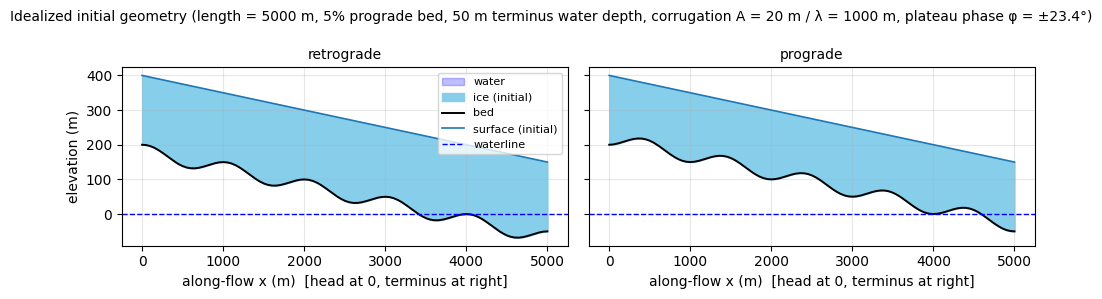

In [8]:
# Orientation: head (inflow Dirichlet boundary, id 1) at x = 0, terminus at
# x = length. Prograde bed: deepest at the terminus (= -water_depth, i.e. the
# bed sits water_depth below the waterline at 0 m) and rising upstream at the
# prograde slope. Corrugation is always applied; both directions are built.
geom_X = np.linspace(0.0, idealized_length, idealized_n_cells + 1)
_bed_prograde = -idealized_water_depth + idealized_bed_slope * (idealized_length - geom_X)

# Phase of the cosine chosen so that d(bed)/dx = 0 at the terminus (level
# plateau) while offset(0) = 0 (terminal water depth preserved). Requires
# |slope · λ / (2π · A)| ≤ 1, i.e. A ≥ slope · λ / (2π); if that's violated
# the plateau can't be reached with this amplitude/wavelength/slope combo.
_A       = idealized_bed_corrugation_amplitude
_lambda  = idealized_bed_corrugation_wavelength
_A_min   = idealized_bed_slope * _lambda / (2 * np.pi)
assert _A >= _A_min, (
    f'Corrugation too gentle for a terminus plateau: A = {_A:.2f} m < '
    f'A_min = slope·λ/(2π) = {_A_min:.2f} m. '
    f'Increase idealized_bed_corrugation_amplitude, or reduce λ or the '
    f'prograde slope.')
_k = idealized_bed_slope * _lambda / (2 * np.pi * _A)
_phase_magnitude = float(np.arcsin(_k))    # 0 ≤ this ≤ π/2

# Both directions are always built.
idealized_directions = ['retrograde', 'prograde']
idealized_configs    = [(sl, d) for sl in sliding_laws for d in idealized_directions]

# Bed and thickness per (sliding_law, direction). Sliding law does not
# influence the initial geometry itself; it's replicated across sliding laws
# only to match the Luggye path's key structure.
geom_bed = {}
geom_thickness = {}
for direction in idealized_directions:
    sign  = {'retrograde': +1, 'prograde': -1}[direction]
    phase = sign * _phase_magnitude
    _s    = idealized_length - geom_X
    _offset = sign * _A * (np.cos(2 * np.pi * _s / _lambda + phase) - np.cos(phase))
    _bed_profile   = _bed_prograde + _offset
    # Initial thickness chosen so that bed + H = _bed_prograde + idealized_thickness
    # everywhere; make_initial_state then delivers a smooth (uncorrugated) initial
    # surface with H thicker over troughs and thinner over ridges.
    _thick_profile = _bed_prograde + idealized_thickness - _bed_profile
    for sl in sliding_laws:
        geom_bed[(sl, direction)]       = _bed_profile.copy()
        geom_thickness[(sl, direction)] = _thick_profile.copy()

# Experiment-mesh resolution / head inflow thickness for this geometry.
length    = idealized_length
n_cells   = idealized_n_cells
H_initial = Constant(idealized_thickness)

# Quick look at the initial idealized geometry — one panel per direction.
_xx = np.linspace(0, length, 400)
fig, axes = plt.subplots(1, len(idealized_directions),
                         figsize=(5 * len(idealized_directions), 3),
                         sharey=True, squeeze=False)
for c, direction in enumerate(idealized_directions):
    ax = axes[0, c]
    _bed_xx = _interp_extrap(_xx, geom_X, geom_bed[(reference_sliding_law, direction)])
    _thk_xx = _interp_extrap(_xx, geom_X, geom_thickness[(reference_sliding_law, direction)])
    _srf_xx = _bed_xx + _thk_xx
    ax.fill_between(_xx, _bed_xx, baseline_waterline, where=_bed_xx < baseline_waterline,
                    color='blue', alpha=0.25, label='water')
    ax.fill_between(_xx, _bed_xx, _srf_xx, color='skyblue', label='ice (initial)')
    ax.plot(_xx, _bed_xx, 'k', lw=1.4, label='bed')
    ax.plot(_xx, _srf_xx, color='tab:blue', lw=1.2, label='surface (initial)')
    ax.axhline(baseline_waterline, color='blue', ls='--', lw=1, label='waterline')
    ax.set_xlabel('along-flow x (m)  [head at 0, terminus at right]')
    if c == 0:
        ax.set_ylabel('elevation (m)')
        ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_title(direction, fontsize=10)
_title = (f'Idealized initial geometry (length = {length:.0f} m, '
          f'{idealized_bed_slope*100:g}% prograde bed, '
          f'{idealized_water_depth:.0f} m terminus water depth, '
          f'corrugation A = {_A:.0f} m / λ = {_lambda:.0f} m, '
          f'plateau phase φ = ±{np.degrees(_phase_magnitude):.1f}°)')
fig.suptitle(_title, fontsize=10)
fig.tight_layout()
plt.show()


In [9]:
# Idealized spin-ups (Section 2.4.1)
# ---------------------------------------------------------------------------
# For each (sliding_law, direction) config — 4 configs total, since both
# corrugation directions are built — spin up the trivial calving law
# (Eq. 5) to steady state and then calibrate the depth-rate and flotation
# laws at that state:
#
#     depth-rate (Eq. 3):  k  = u_t / d_gl
#     flotation  (Eq. 4):  f* = f_af at the terminus
#
# No additional spin-ups are performed, so every calving law begins from the
# same steady-state geometry for its config.

spinup_kwargs = dict(max_time=spinup_max_time,
                     Δt_init=spinup_Δt_init,
                     Δt_final=spinup_Δt_final,
                     Δt_ramp=spinup_Δt_ramp,
                     tol_V_frac=spinup_tol,
                     tol_L_frac=spinup_tol)

print('=' * 70)
print('Spin up each (sliding_law, direction) config once under the trivial')
print('calving law, then calibrate the depth-rate (k) and flotation (f*) laws.')
print('=' * 70)

seeds = {}
bed0s = {}
depth_rate = {}
f_star = {}
baselines = {}

for sl, direction in idealized_configs:

    print(f'\n{sliding_labels[sl]} — {direction}')

    fresh = make_initial_state(sl, direction=direction)
    _, bed0 = prepare_extended_bed(fresh, sl, direction=direction)
    bed0s[(sl, direction)] = bed0

    seed = run_spinup(
        fresh,
        bed0,
        sliding_law=sl,
        calving_law='trivial',
        desc=f'trivial/{sl[:8]}/{direction[:4]}',
        **spinup_kwargs,
    )

    seeds[(sl, direction)] = seed

    k = calibrate_depth_rate(seed, baseline_waterline)
    f = calibrate_f_star(seed, baseline_waterline)

    depth_rate[(sl, direction)] = (
        k if k is not None else per_sliding(depth_rate_default, sl)
    )
    f_star[(sl, direction)] = (
        f if f is not None else per_sliding(f_star_default, sl)
    )

    d = diagnostics(seed)

    print(
        f'  steady state:  '
        f'L = {d["L"]:.0f} m,  '
        f'u_t = {d["u_t"]:.2f} m/yr,  '
        f'd_t = {d["d_t"]:.1f} m'
    )

    print(
        f'  calibrated :  '
        f'k = {depth_rate[(sl, direction)]:.4f} /yr (Eq. 3),  '
        f'f* = {f_star[(sl, direction)]:.4f} (Eq. 4)'
    )

    # Store a baseline entry for every calving law.
    # All three share the same spun-up geometry; only the calibration differs.
    for cl in calving_laws:
        baselines[(sl, direction, cl)] = {
            'state': seed,
            'bed_0': bed0,
            'depth_rate': depth_rate[(sl, direction)],
            'f_star': f_star[(sl, direction)],
        }

print('\n' + '=' * 70)
print('Baseline geometries ready.')
print('All calving laws start from the same trivial steady-state geometry for')
print('their (sliding_law, direction) config; only the calibrated parameters differ.')
print('=' * 70)

for sl, direction in idealized_configs:
    L = diagnostics(seeds[(sl, direction)])["L"]
    print(f'  {sl:20s}/{direction:10s}  L = {L:.0f} m')

print('=' * 70)


Spin up each (sliding_law, direction) config once under the trivial
calving law, then calibrate the depth-rate (k) and flotation (f*) laws.

power-law sliding (Eq 1) — retrograde


trivial/power_la/retr:   0%|          | 0/200.0 [00:00<?, ?yr/s]

    [trivial/power_la/retr] converged at t = 136 yr  (dV/V/dt = -9.8e-05/yr, dL/L/dt = +0.0e+00/yr)
  steady state:  L = 5000 m,  u_t = 27.48 m/yr,  d_t = 50.0 m
  calibrated :  k = 0.5497 /yr (Eq. 3),  f* = 0.2329 (Eq. 4)

power-law sliding (Eq 1) — prograde


trivial/power_la/prog:   0%|          | 0/200.0 [00:00<?, ?yr/s]

    [trivial/power_la/prog] converged at t = 21 yr  (dV/V/dt = -6.9e-05/yr, dL/L/dt = +0.0e+00/yr)
  steady state:  L = 5000 m,  u_t = 28.66 m/yr,  d_t = 50.0 m
  calibrated :  k = 0.5732 /yr (Eq. 3),  f* = 0.1964 (Eq. 4)

effective-pressure sliding (Eq 2) — retrograde


trivial/effectiv/retr:   0%|          | 0/200.0 [00:00<?, ?yr/s]

    [trivial/effectiv/retr] converged at t = 142 yr  (dV/V/dt = -9.8e-05/yr, dL/L/dt = +0.0e+00/yr)
  steady state:  L = 5000 m,  u_t = 28.95 m/yr,  d_t = 50.0 m
  calibrated :  k = 0.5789 /yr (Eq. 3),  f* = 0.1987 (Eq. 4)

effective-pressure sliding (Eq 2) — prograde


trivial/effectiv/prog:   0%|          | 0/200.0 [00:00<?, ?yr/s]

    [trivial/effectiv/prog] converged at t = 25 yr  (dV/V/dt = -7.3e-05/yr, dL/L/dt = +0.0e+00/yr)
  steady state:  L = 5000 m,  u_t = 31.73 m/yr,  d_t = 50.0 m
  calibrated :  k = 0.6346 /yr (Eq. 3),  f* = 0.1251 (Eq. 4)

Baseline geometries ready.
All calving laws start from the same trivial steady-state geometry for
their (sliding_law, direction) config; only the calibrated parameters differ.
  power_law           /retrograde  L = 5000 m
  power_law           /prograde    L = 5000 m
  effective_pressure  /retrograde  L = 5000 m
  effective_pressure  /prograde    L = 5000 m


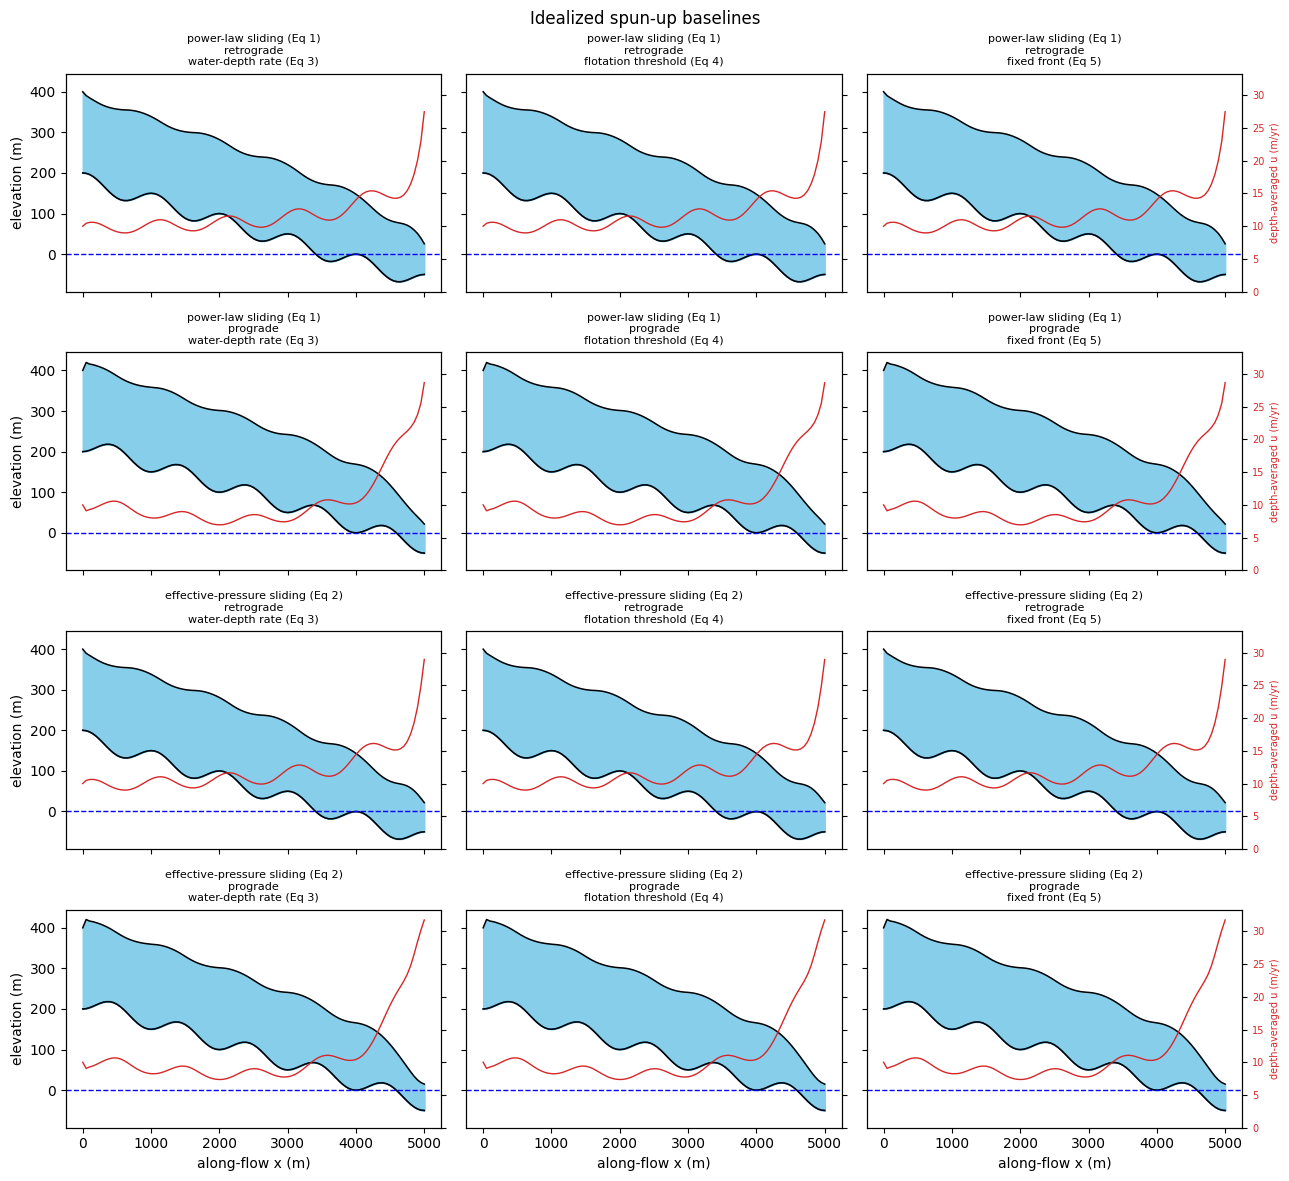

In [10]:
# Spun-up baseline profiles (supporting figure, reused by the Luggye section).
def plot_baseline_profiles(baselines, tag, title):
    """Grid of baseline profiles: one row per (sliding_law, direction) config
    present in `baselines`, one column per calving law. Each panel shows the
    ice / bed / water geometry on the left y-axis and the depth-averaged
    velocity along the flowline on the twin right y-axis (shared scale across
    all panels of the figure so panels are directly comparable)."""

    # Discover the (sliding_law, direction) configs present in baselines and
    # order them: first by sliding_law (in the shared-parameters order), then
    # by direction (none → retrograde → prograde).
    configs = sorted(
        set((k[0], k[1]) for k in baselines.keys()),
        key=lambda p: (sliding_laws.index(p[0]), direction_order.index(p[1])),
    )

    fig, axes = plt.subplots(len(configs), len(calving_laws),
                             figsize=(13, 3 * len(configs)),
                             sharex=True, sharey=True, squeeze=False)

    # First pass: collect u_bar across every panel to pick a shared right-axis
    # scale so panels are directly comparable.
    u_max = 0.0
    for (sl, direction) in configs:
        for cl in calving_laws:
            state = baselines[(sl, direction, cl)]['state']
            u_arr = np.array(icepack.depth_average(state['u']).at(
                state['mesh'].X, tolerance=1e-10))
            if len(u_arr):
                u_max = max(u_max, float(np.nanmax(np.abs(u_arr))))
    u_lim = (0.0, u_max * 1.05 if u_max > 0 else 1.0)

    for r, (sl, direction) in enumerate(configs):
        for c, cl in enumerate(calving_laws):
            ax = axes[r, c]
            state = baselines[(sl, direction, cl)]['state']
            mesh, H, s, bed, u = state['mesh'], state['H'], state['s'], state['bed'], state['u']
            base = firedrake.project(s - H, s.function_space())
            x = mesh.X
            order    = np.argsort(np.asarray(x, dtype=float))
            s_arr    = np.array(icepack.depth_average(s).at(x, tolerance=1e-10))[order]
            base_arr = np.array(icepack.depth_average(base).at(x, tolerance=1e-10))[order]
            bed_arr  = np.array(icepack.depth_average(bed).at(x, tolerance=1e-10))[order]
            u_arr    = np.array(icepack.depth_average(u).at(x, tolerance=1e-10))[order]
            x_arr    = np.asarray(x)[order]

            # Geometry on the left y-axis.
            ax.fill_between(x_arr, bed_arr, baseline_waterline,
                            where=bed_arr < baseline_waterline,
                            color='blue', alpha=0.30)
            ax.fill_between(x_arr, base_arr, s_arr, color='skyblue')
            ax.plot(x_arr, s_arr,    'k',        lw=1.1)
            ax.plot(x_arr, base_arr, 'tab:blue', lw=1.1)
            ax.plot(x_arr, bed_arr,  'k',        lw=1.1)
            ax.axhline(baseline_waterline, color='blue', ls='--', lw=1)

            # Depth-averaged velocity on the twin right y-axis, shared scale.
            ax2 = ax.twinx()
            ax2.plot(x_arr, u_arr, color='tab:red', lw=1.0)
            ax2.set_ylim(*u_lim)
            ax2.tick_params(axis='y', labelcolor='tab:red', labelsize=7)
            if c == len(calving_laws) - 1:
                ax2.set_ylabel('depth-averaged u (m/yr)', color='tab:red', fontsize=7)
            else:
                ax2.set_yticklabels([])

            # Title carries sliding law, direction (if not 'none'), and calving law.
            title_bits = [sliding_labels[sl]]
            if direction != 'none':
                title_bits.append(direction)
            title_bits.append(calving_labels[cl])
            ax.set_title('\n'.join(title_bits), fontsize=8)
            if r == len(configs) - 1:
                ax.set_xlabel('along-flow x (m)')
            if c == 0:
                ax.set_ylabel('elevation (m)')

    fig.suptitle(title, fontsize=12)
    fig.tight_layout()
    fig.savefig(f'{figures_path}/{tag}_baseline_profiles.png', dpi=120, bbox_inches='tight')
    plt.show()


plot_baseline_profiles(baselines, 'idealized', 'Idealized spun-up baselines')


idealized: configs:   0%|          | 0/4 [00:00<?, ?it/s]

idealized: power_law/retrograde:   0%|          | 0/3 [00:00<?, ?it/s]

idealized: power_law/retrograde/depth_rate:   0%|          | 0/21 [00:00<?, ?it/s]

idealized: power_law/retrograde/flotation:   0%|          | 0/21 [00:00<?, ?it/s]

idealized: power_law/retrograde/trivial:   0%|          | 0/21 [00:00<?, ?it/s]

...

idealized: effective_pressure/retrograde/trivial:   0%|          | 0/21 [00:00<?, ?it/s]

idealized: effective_pressure/prograde:   0%|          | 0/3 [00:00<?, ?it/s]

idealized: effective_pressure/prograde/depth_rate:   0%|          | 0/21 [00:00<?, ?it/s]

idealized: effective_pressure/prograde/flotation:   0%|          | 0/21 [00:00<?, ?it/s]

idealized: effective_pressure/prograde/trivial:   0%|          | 0/21 [00:00<?, ?it/s]

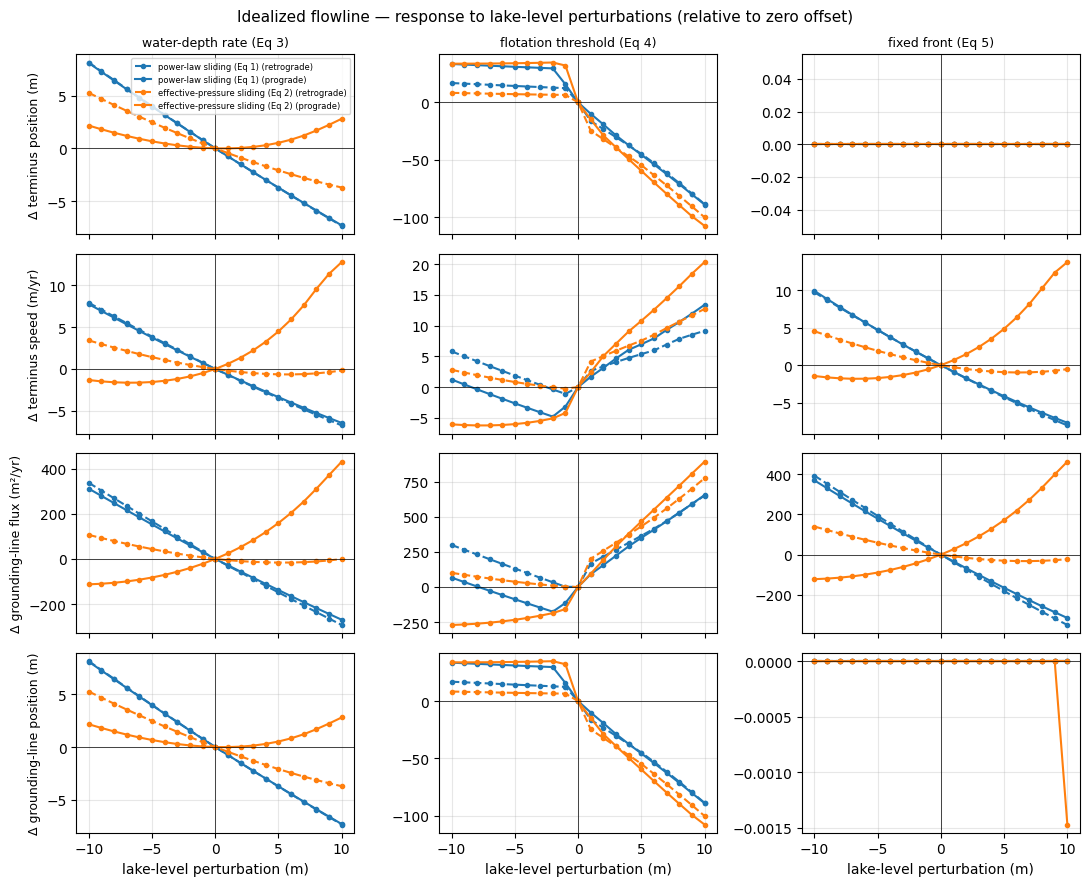

In [11]:
# Idealized perturbation experiments: 6 baselines x len(waterline_offsets)
# runs, each reported relative to its baseline's zero-offset run.
idealized_final = run_all_experiments(baselines, 'idealized', configs=idealized_configs)
plot_response(idealized_final, 'idealized',
              'Idealized flowline — response to lake-level perturbations '
              '(relative to zero offset)')


*Figure 1 (idealized).* Response to the lake-level perturbation sweep for the idealized flowline. The waterline is ramped linearly from the baseline to the target offset over the ramp phase and then held at the target for the hold phase (both configurable at the top of the notebook); each panel shows the end-of-hold value of one diagnostic, differenced against the offset = 0 run of the same baseline. Rows are the four diagnostics: change in terminus position, change in terminus speed, change in grounding-line flux (expressed as a mean rate over the experiment), and change in grounding-line position — the most-downstream point at which the ice is still grounded, evaluated at the final state. Columns are the three calving laws, and the two curves in each panel are the two sliding laws. *Results prose to be written once the experiments have been run.*

### 3.2 Luggye flowline model

We now repeat the experiment on Luggye Glacier. Following Section 2.4.2, basal topography is recovered by the van Pelt et al. (2013) forward-model inversion (`solve_bed`), run once per sliding law under the trivial calving law (which holds the terminus fixed during the inversion). The post-inversion surface and thickness — the geometry "as it is at the end of each bed inversion" — provide the experiment's initial state directly; we do **not** spin up further. The depth-rate and flotation laws are made self-consistent at this geometry by the same calibration used for the idealized case ($k = u_t/d_{gl}$, $f^* = f_{af}$ at the terminus).

> The inversion cell reads cluster-local data (drone DEM, RGI outlines/centerlines, velocity, thickness, SMB). **Edit the paths at the top of the cell to match your environment.** The inversion is expensive and is guarded so it runs once per kernel session; set `force_rerun_inversion = True` to redo it.

  inversion mesh: length = 2077 m, cell size ~ 4 m
  inverting bed for sliding law = power_law ...


100%|██████████| 30/30 [02:57<00:00,  5.92s/it]


  inverting bed for sliding law = effective_pressure ...


100%|██████████| 30/30 [03:18<00:00,  6.61s/it]


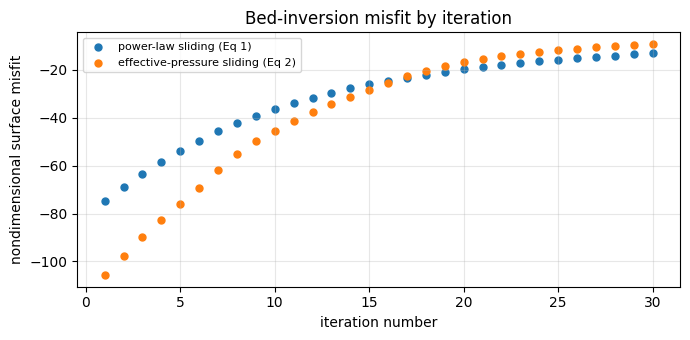

  inverted 2 bed(s); length = 2077 m
    [power_law           ] bed range = [-111, 796] m | terminus bed = -100 m
    [effective_pressure  ] bed range = [-47, 796] m | terminus bed = -43 m


In [12]:
# Inline basal-topography inversion for Luggye Glacier (Lunana, Bhutan)
# ---------------------------------------------------------------------------
# One bed per sliding law (2 inversions), each under the trivial calving law
# (solve_bed holds the terminus fixed). Outputs are the along-flow coordinate
# inv_X (shared) and per-sliding-law profiles inv_bed / inv_surface /
# inv_thickness. All inversion-local names are prefixed inv_ so they never
# clobber the experiment globals (A, C, mesh, n_cells, ...). In particular
# the inversion keeps its own fluidity/friction (inv_A, inv_C) hardcoded
# just below, deliberately different from the experiment globals: the
# Luggye surface DEM is treated as ~steady under warmer, more-slippery
# assumptions than the perturbation experiments use.
#
# real_target_cell_size sets the resolution of the clean experiment mesh that
# the inverted profile is later mapped onto (Section 3.2 setup cell).
real_target_cell_size = 25.0     # m
force_rerun_inversion = False


def _inversion_friction(water_aware):
    """Basal-friction callable for the INVERSION forward model, matching the
    experiment's sliding-law shapes (waterline = 0 frame): constant traction for
    'power_law', flotation-scaled (clamped to [0.01, 1]) for
    'effective_pressure'."""
    def friction(**kwargs):
        H = kwargs['thickness']; s = kwargs['surface']
        u = kwargs['velocity'];  Cf = kwargs['friction']
        rho = icepack.constants.ice_density / icepack.constants.water_density
        h_af = s - (1 - rho) * H
        frac_af = (firedrake.min_value(firedrake.max_value(h_af / H, 0.01), 1)
                   if water_aware else 1)
        return icepack.models.hybrid.bed_friction(velocity=u, friction=Cf * frac_af)
    return friction


if force_rerun_inversion or 'inv_bed' not in globals():
    # ---- data paths (cluster-specific; EDIT to match your layout) -----------
    rgiid_6 = '15.02373'    # RGI 6.0 id (most data)
    rgiid_7 = '15-09534'    # RGI 7.0 id (outlines / velocity)
    base_path = '/eejit/home/bezu0001/data/'
    centerline_path = base_path + 'centerlines/RGI2000-v7.0-L-15_south_asia_east/RGI2000-v7.0-L-15_south_asia_east.shp'
    outline_path    = base_path + 'outlines/RGI2000-v7.0-G-15_south_asia_east/RGI2000-v7.0-G-15_south_asia_east.shp'
    velocity_path   = base_path + f'velocity/{rgiid_7}/MedianVelocity_2006.tif'
    dem_path        = '/eejit/home/bezu0001/field_data/drone/dems/Luggye_2025.tif'
    thickness_path  = base_path + f'thickness/farinotti_model_2/thickness_RGI60-{rgiid_6}.tif'
    smb_path        = base_path + 'smb/karma/prf_glacier_ctl.csv'

    # ---- inversion mesh and observational data (built ONCE) -----------------
    inv_n_cells   = 500
    inv_waterline = 4480    # elevation (m) of the lake surface in the source DEM

    # Bed-inversion time control (van Pelt method): each iteration forward-models
    # for exactly inversion_model_time (1 yr) at a fixed short step. Local to
    # this cell — deliberately separate from the idealized spin-up and the
    # perturbation-experiment time controls.
    inversion_timestep    = 1/100   # yr; fixed step within each inversion iteration
    inversion_model_time  = 1.0     # yr; forward-model duration per iteration
    inversion_iterations  = 30      # number of bed-correction iterations
    inversion_K           = 0.1     # bed-correction gain

    inv_mesh = centerline_mesh(rgiid=rgiid_7, centerline_path=centerline_path,
                               outline_path=outline_path, n_cells=inv_n_cells)
    inv_mesh = crop_mesh(mesh=inv_mesh, data_path=dem_path, min_height=inv_waterline + 20)
    inv_cell_size = int(inv_mesh.length / inv_n_cells)
    print(f'  inversion mesh: length = {inv_mesh.length:.0f} m, cell size ~ {inv_cell_size} m')

    inv_thickness_obs = map_to_mesh(mesh=inv_mesh, data_path=thickness_path)
    inv_dem           = map_to_mesh(mesh=inv_mesh, data_path=dem_path)
    inv_smb           = map_to_mesh(mesh=inv_mesh, data_path=smb_path,
                                    key_value=' altitude', key_dataset=inv_dem,
                                    data_value='ave_mb')
    inv_velocity      = map_to_mesh(mesh=inv_mesh, data_path=velocity_path, ice_free_value=0)

    inv_Q = inv_dem.function_space()
    inv_V = FunctionSpace(inv_mesh.mesh, 'CG', 1, vfamily='GL', vdegree=2)
    inv_X_raw = inv_mesh.mesh._base_mesh.coordinates.dat.data_ro.flatten()

    inv_smoothing     = {'window': 3 * inv_cell_size, 'mesh': inv_mesh}
    inv_smb_adj       = Function(inv_Q).project(inv_smb + 3)
    inv_smb_adj       = smooth_function(function=inv_smb_adj, **inv_smoothing)
    inv_dem           = Function(inv_Q).project(inv_dem - inv_waterline)
    inv_dem           = smooth_function(function=inv_dem, **inv_smoothing)
    inv_thickness_obs = smooth_function(function=inv_thickness_obs, **inv_smoothing)
    inv_velocity      = smooth_function(function=inv_velocity, **inv_smoothing)
    inv_u             = Function(inv_V).project(1e-10 * inv_velocity)  # ~zero inflow BC

    # Inversion-only fluidity and friction. Kept hardcoded here so the
    # inversion has stable physics regardless of what the experiment
    # globals (T, A, C in cell 11) are set to — this is what makes the
    # solve_bed forward model well-conditioned on the observed Luggye
    # geometry.
    inv_A = Constant(icepack.rate_factor(273.15 - 0))    # 0 °C
    inv_C = Constant(0.1)                                # 0.1

    # ---- invert the bed once per sliding law (trivial calving) --------------
    inv_bed, inv_surface, inv_thickness, inv_misfits = {}, {}, {}, {}
    for sl in sliding_laws:
        wa = (sl == 'effective_pressure')
        inv_model  = icepack.models.HybridModel(friction=_inversion_friction(wa))
        inv_solver = icepack.solvers.FlowSolver(inv_model, dirichlet_ids=[1])
        print(f'  inverting bed for sliding law = {sl} ...')
        inversion = solve_bed(K=inversion_K, num_iterations=inversion_iterations,
                              timestep=inversion_timestep, model_time=inversion_model_time,
                              surface=inv_dem, thickness_guess=Constant(200),
                              velocity=inv_u, accumulation=inv_smb_adj,
                              model=inv_model, solver=inv_solver,
                              mesh=inv_mesh, fluidity=inv_A, friction=inv_C)
        inv_bed[sl]       = np.asarray(inversion.bed_evolution[-1], float)
        inv_surface[sl]   = np.asarray(inversion.surface_evolution[-1], float)
        inv_thickness[sl] = np.asarray(inversion.thickness_evolution[-1], float)
        inv_misfits[sl]   = np.asarray(inversion.misfits, float)

    # ---- misfit vs iteration (diagnostic) -----------------------------------
    plt.figure(figsize=(7, 3.5))
    for sl in sliding_laws:
        plt.scatter(np.arange(1, len(inv_misfits[sl]) + 1), inv_misfits[sl], s=25,
                    color=sliding_colors[sl], label=sliding_labels[sl])
    plt.xlabel('iteration number'); plt.ylabel('nondimensional surface misfit')
    plt.title('Bed-inversion misfit by iteration')
    plt.grid(alpha=0.3); plt.legend(fontsize=8); plt.tight_layout(); plt.show()

    # ---- orient/zero-base the shared coordinate, apply to every bed ---------
    inv_X = np.asarray(inv_X_raw, float)
    _o = np.argsort(inv_X)
    inv_X = inv_X[_o] - inv_X[_o][0]
    for sl in list(inv_bed):
        inv_bed[sl], inv_surface[sl], inv_thickness[sl] = (
            inv_bed[sl][_o], inv_surface[sl][_o], inv_thickness[sl][_o])

    # Orientation: terminus (lake contact; lowest bed) at HIGH x, head (inflow
    # Dirichlet boundary, id 1) at x = 0. Decide from the reference bed and flip
    # all profiles together if needed.
    _refb = inv_bed.get(reference_sliding_law, next(iter(inv_bed.values())))
    _k = max(1, len(inv_X) // 10)
    if _refb[:_k].mean() < _refb[-_k:].mean():
        inv_X = (inv_X[-1] - inv_X)[::-1]
        for sl in list(inv_bed):
            inv_bed[sl], inv_surface[sl], inv_thickness[sl] = (
                inv_bed[sl][::-1], inv_surface[sl][::-1], inv_thickness[sl][::-1])
        print('  geometry: flipped so terminus is at high x')

    print(f'  inverted {len(inv_bed)} bed(s); length = {inv_X[-1]:.0f} m')
    for sl in inv_bed:
        print(f'    [{sl:20s}] bed range = [{inv_bed[sl].min():.0f}, {inv_bed[sl].max():.0f}] m '
              f'| terminus bed = {inv_bed[sl][-1]:.0f} m')


Luggye experiment mesh: length = 2077 m | n_cells = 83 | cell size ~ 25.0 m | head inflow H = 15 m
  power_law: L = 2077 m, u_t = 69.63 m/yr, x_gl = 2077 m, d_gl = 100.0 m -> k = 0.6961 /yr, f* = 0.1786
  effective_pressure: L = 2077 m, u_t = 60.93 m/yr, x_gl = 2077 m, d_gl = 43.0 m -> k = 1.4161 /yr, f* = 0.3486


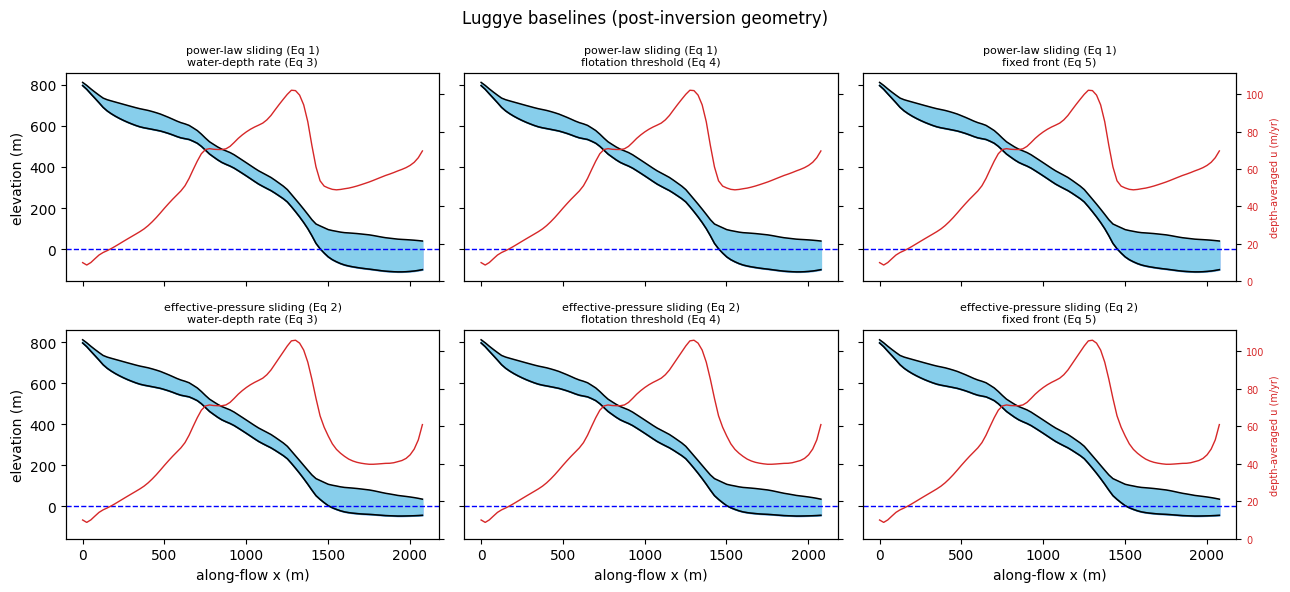

In [13]:
# Luggye baselines from the END-OF-INVERSION geometry (Section 2.4.2)
# ---------------------------------------------------------------------------
# The experiment starts from the modeled thickness at the end of the last
# bed-inversion iteration (`inv_thickness`), NOT from the observed thickness
# (`inv_thickness_obs`). The modeled thickness has been "settled" through the
# bed-correction iterations. make_initial_state re-projects
# it onto a fresh straight-flowline mesh and recomputes the surface from
# bed + H for consistency with the flotation treatment. No additional spin-up
# is performed.
#
# Luggye has no corrugation dimension, so direction is fixed to 'none' and
# `luggye_configs` has 2 entries (one per sliding law).
geom_X         = inv_X
geom_bed       = {(sl, 'none'): inv_bed[sl]       for sl in sliding_laws}
geom_thickness = {(sl, 'none'): inv_thickness[sl] for sl in sliding_laws}
length  = float(geom_X[-1])
n_cells = max(50, int(round(length / real_target_cell_size)))
_hl = reference_sliding_law if reference_sliding_law in inv_thickness else next(iter(inv_thickness))
H_initial = Constant(float(max(inv_thickness[_hl][0], min_thickness)))
print(f'Luggye experiment mesh: length = {length:.0f} m | n_cells = {n_cells} '
      f'| cell size ~ {length/n_cells:.1f} m | head inflow H = {float(H_initial):.0f} m')

luggye_configs = [(sl, 'none') for sl in sliding_laws]


def solved_state(sliding_law, direction='none', waterline=baseline_waterline):
    """End-of-inversion geometry with ONE diagnostic momentum solve so the
    velocity field is consistent with the geometry (needed for calving
    calibration). No thickness evolution — this is not a spin-up. Uses the
    global A, C bound in cell 11."""
    st = make_initial_state(sliding_law, direction=direction)
    wa = (sliding_law == 'effective_pressure')
    solver = make_flow_solver(waterline=waterline, water_aware_friction=wa)
    st['u'] = solver.diagnostic_solve(velocity=st['u'], thickness=st['H'],
                                      surface=st['s'], fluidity=A, friction=C)
    return st


# Build the six baselines. Within a sliding law all three calving laws start
# from the same post-inversion state; only the calving tuning differs.
baselines = {}
depth_rate, f_star = {}, {}
for sl, direction in luggye_configs:
    base_state = solved_state(sl, direction=direction)
    _, b0 = prepare_extended_bed(base_state, sl, direction=direction)
    kr = calibrate_depth_rate(base_state, baseline_waterline)
    fr = calibrate_f_star(base_state, baseline_waterline)
    depth_rate[(sl, direction)] = kr if kr is not None else per_sliding(depth_rate_default, sl)
    f_star[(sl, direction)]     = fr if fr is not None else per_sliding(f_star_default, sl)
    d = diagnostics(base_state)
    d_gl, x_gl = grounding_line_depth(base_state, baseline_waterline)
    print(f'  {sl}: L = {d["L"]:.0f} m, u_t = {d["u_t"]:.2f} m/yr, '
          f'x_gl = {x_gl:.0f} m, d_gl = {d_gl:.1f} m '
          f'-> k = {depth_rate[(sl, direction)]:.4f} /yr, f* = {f_star[(sl, direction)]:.4f}')
    for cl in calving_laws:
        baselines[(sl, direction, cl)] = {
            'state': base_state, 'bed_0': b0,
            'depth_rate': depth_rate[(sl, direction)],
            'f_star':     f_star[(sl, direction)],
        }

plot_baseline_profiles(baselines, 'luggye', 'Luggye baselines (post-inversion geometry)')


luggye: configs:   0%|          | 0/2 [00:00<?, ?it/s]

luggye: power_law/none:   0%|          | 0/3 [00:00<?, ?it/s]

luggye: power_law/none/depth_rate:   0%|          | 0/21 [00:00<?, ?it/s]

luggye: power_law/none/flotation:   0%|          | 0/21 [00:00<?, ?it/s]

luggye: power_law/none/trivial:   0%|          | 0/21 [00:00<?, ?it/s]

luggye: effective_pressure/none:   0%|          | 0/3 [00:00<?, ?it/s]

luggye: effective_pressure/none/depth_rate:   0%|          | 0/21 [00:00<?, ?it/s]

luggye: effective_pressure/none/flotation:   0%|          | 0/21 [00:00<?, ?it/s]

luggye: effective_pressure/none/trivial:   0%|          | 0/21 [00:00<?, ?it/s]

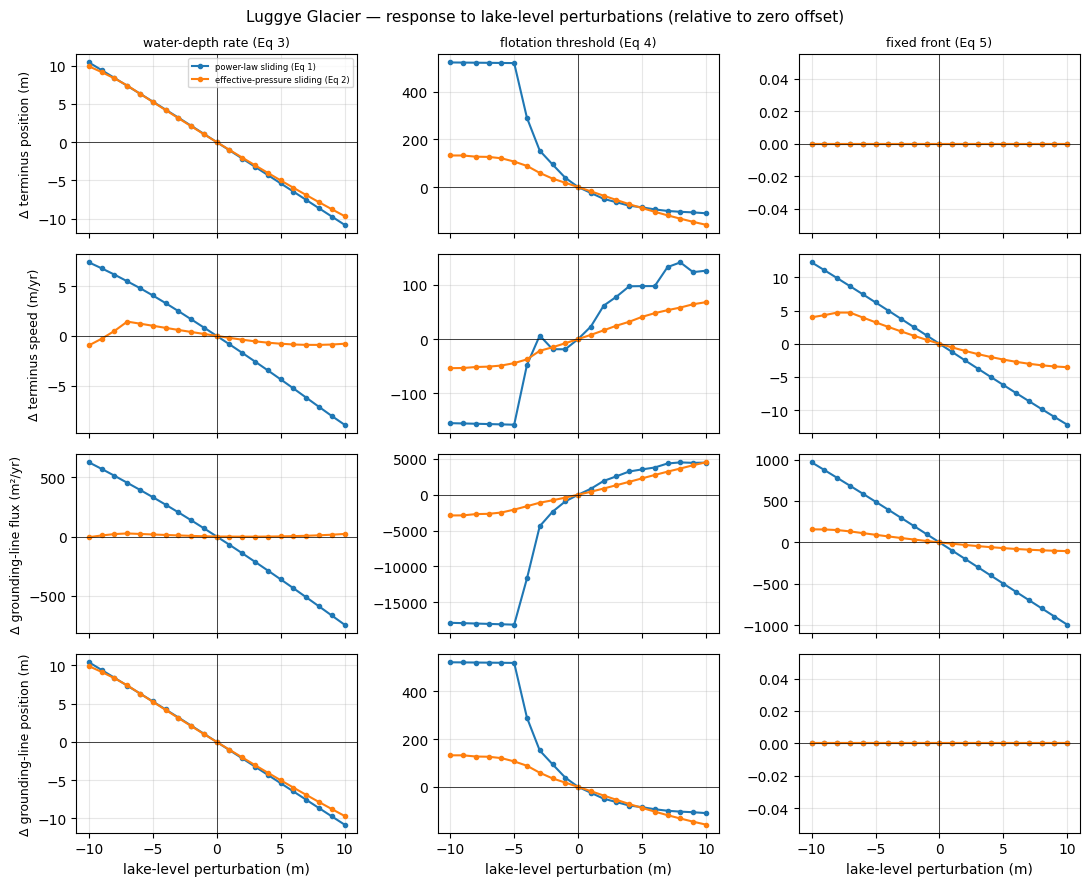

In [14]:
# Luggye perturbation experiments: 6 baselines x len(waterline_offsets)
# runs, each reported relative to its baseline's zero-offset run.
luggye_final = run_all_experiments(baselines, 'luggye', configs=luggye_configs)
plot_response(luggye_final, 'luggye',
              'Luggye Glacier — response to lake-level perturbations '
              '(relative to zero offset)')


*Figure 2 (Luggye).* As Figure 1, for the observation-informed Luggye Glacier geometry. Each baseline begins from the post-inversion surface for its sliding law; the rows show the same four diagnostics (Δ terminus position, Δ terminus speed, Δ grounding-line flux as a mean rate, and Δ grounding-line position at the final state), differenced against the offset = 0 run of the same baseline. *Results prose to be written once the experiments have been run.*

### Appendix: per-step diagnostic for the flotation-law anomaly at Luggye

Figure 2's flotation column shows Δ terminus position values of order ±200 m over a 1-yr window — well beyond what advance at u_t (~24 m/yr) can produce. This cell traces four Luggye experiments step-by-step to expose the mechanism. Each panel of the small figure below is one of the four diagnostics that step_with_remeshing now records at every step: the terminus position L, the depth-averaged terminus speed u_t, the fraction above flotation at the terminus (with the calibrated $f^*$ drawn as a dotted line), and the per-step advance $\Delta x = L_\mathrm{new} - L_0$. Three cases exercise the flotation law at offsets −10, 0, and +10 m; the fourth (depth-rate at offset = −10) is a control that behaves sensibly.

Read the panels together. If u_t stays near its spun-up value throughout the run *and* Δx per step never exceeds $u_t \cdot \Delta t$, the anomaly is not velocity runaway on the extending tongue. If u_t grows over the run and Δx per step grows with it, the mechanism is that each ramp step extends the mesh into deeper water, where the effective-pressure friction floors at 0.01, and the next diagnostic solve sees a nearly frictionless downstream slab. The full per-step trace of the offset = −10 flotation case is printed below the figure to make L_proposed vs. L_adv legible.

In [ ]:
# Per-step trace of a handful of Luggye experiments. Requires baselines from
# Section 3.2 (cell 24) and the run_experiment / f_star bindings from those.
trace_cases = [
    ('power_law', 'flotation',  -10.0),   # the anomalous ~+200 m dL case
    ('power_law', 'flotation',    0.0),   # its baseline
    ('power_law', 'flotation',  +10.0),   # the anomalous ~−200 m dL case
    ('power_law', 'depth_rate', -10.0),   # control — same conditions, different law
]

traces = {}
for sl, cl, off in trace_cases:
    tr = []
    _ = run_experiment(baselines, sl, cl, off, trace=tr)
    traces[(sl, cl, off)] = pd.DataFrame(tr)

# Four-panel per-step trace.
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
ax_L, ax_u, ax_faf, ax_dx = axes.ravel()
for (sl, cl, off), df in traces.items():
    lbl = f'{cl}, off={off:+.0f}'
    ls  = '-' if cl == 'flotation' else '--'
    ax_L  .plot(df['step_idx'], df['L_new'],         marker='o', ms=3, ls=ls, label=lbl)
    ax_u  .plot(df['step_idx'], df['u_t'],           marker='o', ms=3, ls=ls, label=lbl)
    ax_faf.plot(df['step_idx'], df['f_af_terminus'], marker='o', ms=3, ls=ls, label=lbl)
    ax_dx .plot(df['step_idx'], df['Δx'],            marker='o', ms=3, ls=ls, label=lbl)

ax_L  .set_ylabel('L (m)')
ax_u  .set_ylabel('u_t (m/yr)')
ax_faf.set_ylabel('f_af at terminus')
ax_faf.axhline(f_star['power_law'], color='k', lw=0.5, ls=':',
               label=f'f* = {f_star["power_law"]:.3f}')
ax_dx .set_ylabel('Δx per step (m)')
for ax in (ax_faf, ax_dx):
    ax.set_xlabel('step index')
for ax in axes.ravel():
    ax.grid(True, alpha=0.3)
ax_L  .legend(loc='best', fontsize=8)
ax_faf.legend(loc='best', fontsize=8)
fig.suptitle('Luggye flotation-law diagnostic: per-step trace')
fig.tight_layout()
plt.show()

# One-line summary per case.
print()
hdr = f'{"case":48s}  {"L₀":>8s}  {"L_final":>8s}  {"peak u_t":>10s}  {"final f_af":>12s}  {"peak Δx":>10s}'
print(hdr)
print('-' * len(hdr))
for (sl, cl, off), df in traces.items():
    tag = f'{sl}/{cl}/off={off:+.1f}'
    print(f'{tag:48s}  '
          f'{df["L_0"].iloc[0]:>8.1f}  '
          f'{df["L_new"].iloc[-1]:>8.1f}  '
          f'{df["u_t"].max():>10.2f}  '
          f'{df["f_af_terminus"].iloc[-1]:>+12.4f}  '
          f'{df["Δx"].max():>10.2f}')

# Full per-step trace of the anomaly case. L_proposed is either +inf
# (no calving constraint — advance at u_t) or a finite value; both are worth
# seeing directly.
key = ('power_law', 'flotation', -10.0)
print(f'\nFull per-step trace for {key}:')
cols = ['step_idx', 'waterline', 'L_0', 'L_new', 'L_adv', 'L_proposed',
        'Δx', 'u_t', 'f_af_terminus']
with pd.option_context('display.max_columns', None, 'display.width', 160,
                       'display.float_format', '{:.3f}'.format):
    print(traces[key][cols].to_string(index=False))


## 4 Discussion and conclusions

*To be completed once the experiments above have been run.* The anticipated result, stated in the Abstract, is that a lake-level rise drives near-terminus thinning, speedup, and increased calving flux across the sliding and calving laws, while a lake-level drop slows the terminus and reduces calving flux — with the practical implication that an artificial reduction of proglacial lake level may be an effective GLOF-risk mitigation technique. Points to address here include: (i) whether the sign of the response is consistent across the two sliding laws and three calving laws, and where (if anywhere) it is not; (ii) the relative magnitude of the idealized versus Luggye responses; and (iii) justification of the modelling choice to invert a single bed per sliding law (under the trivial calving law) rather than a distinct bed per sliding–calving pair.

## 5 Open Research

Running the notebook writes per-experiment diagnostics to `./data_icepack/idealized_response.csv` and `./data_icepack/luggye_response.csv`, and figures to `./figures_icepack/`. For submission, deposit these outputs — together with the inverted Luggye geometry and the drone-DEM / RGI / velocity / thickness / SMB inputs used by the inversion — in an archive `[CITE: archive DOI]`. The icepack package is available at https://github.com/icepack/icepack (Shapero et al., 2021); the `centerflow_extruded` helper module is distributed alongside this notebook.

## Acknowledgments

Include acknowledgements here.

## References

- Ahmed, R., Wani, G. F., Ahmad, S. T., Sahana, M., Singh, H., & Ahmed, P. (2021). A review of glacial lake expansion and associated glacial lake outburst floods in the Himalayan region (Vol. 5). Springer Science and Business Media Deutschland GmbH. https://doi.org/10.1007/s41748-021-00230-9
- Amaral, T., Bartholomaus, T. C., & Enderlin, E. M. (2020). Evaluation of iceberg calving models against observations from Greenland outlet glaciers. *Journal of Geophysical Research: Earth Surface*, 1–29. https://doi.org/10.1029/2019JF005444
- Blatter, H. (1995). Velocity and stress fields in grounded glaciers: a simple algorithm for including deviatoric stress gradients. *Journal of Glaciology*, 41, 333–344. https://doi.org/10.1017/S002214300001621X
- Budd, W. F., Jenssen, D., & Smith, I. N. (1984). A three-dimensional time-dependent model of the West Antarctic ice sheet. *Annals of Glaciology*, 5, 29–36. https://doi.org/10.3189/1984aog5-1-29-36
- Budd, W. F., Keage, P. L., & Blundy, N. A. (1979). Empirical studies of ice sliding. *Journal of Glaciology*, 23, 157–170. https://doi.org/10.3189/s0022143000029804
- Cuffey, K. M., & Paterson, W. S. B. (2010). *The physics of glaciers* (4th ed.). Butterworth-Heinemann. https://doi.org/10.3189/002214311796405906
- Hugonnet, R., McNabb, R., Berthier, E., Menounos, B., Nuth, C., Girod, L., … Kääb, A. (2021). Accelerated global glacier mass loss in the early twenty-first century. *Nature*, 592, 726–731. https://doi.org/10.1038/s41586-021-03436-z
- Hutter, K. (1983). *Theoretical glaciology: Material science of ice and the mechanics of glaciers and ice sheets*. D. Reidel Publishing Co. https://doi.org/10.1016/0165-232x(84)90039-9
- King, O., Dehecq, A., Quincey, D., & Carrivick, J. (2018). Contrasting geometric and dynamic evolution of lake and land-terminating glaciers in the central Himalaya. *Global and Planetary Change*, 167, 46–60. https://doi.org/10.1016/j.gloplacha.2018.05.006
- MacAyeal, D. R. (1989). Large-scale ice flow over a viscous basal sediment: theory and application to ice stream B, Antarctica. *Journal of Geophysical Research*, 94, 4071–4087.
- Maurer, J. M., Schaefer, J. M., Russell, J. B., Rupper, S., Wangdi, N., Putnam, A. E., & Young, N. (2020). Seismic observations, numerical modeling, and geomorphic analysis of a glacier lake outburst flood in the Himalayas (Vol. 6).
- Mir, R. A., Jain, S. K., Ahmed, R., & Rather, A. F. (2025). A strategic framework for glacial lake outburst flood (GLOF) risk reduction in the Himalayas under climate change. *Discover Geoscience*, 3. https://doi.org/10.1007/s44288-025-00230-6
- Morland, L. W. (1987). Unconfined ice-shelf flow. In *Dynamics of the West Antarctic Ice Sheet* (Vol. 28, pp. 5241–5244).
- Nie, Y., Liu, Q., Wang, J., Zhang, Y., Sheng, Y., & Liu, S. (2018). An inventory of historical glacial lake outburst floods in the Himalayas based on remote sensing observations and geomorphological analysis. *Geomorphology*, 308, 91–106. https://doi.org/10.1016/j.geomorph.2018.02.002
- Oerlemans, J., & Nick, F. M. (2005). A minimal model of a tidewater glacier. *Annals of Glaciology*, 1–6. https://doi.org/10.3189/172756405781813023
- Pattyn, F. (2002). Transient glacier response with a higher-order numerical ice-flow model. *Journal of Glaciology*, 48, 467–476. https://doi.org/10.3189/172756502781831278
- Pelt, W. J. V., Oerlemans, J., Reijmer, C. H., Pettersson, R., Pohjola, V. A., Isaksson, E., & Divine, D. (2013). An iterative inverse method to estimate basal topography and initialize ice flow models. *The Cryosphere*, 7, 987–1006. https://doi.org/10.5194/tc-7-987-2013
- Recinos, B., Maussion, F., Rothenpieler, T., & Marzeion, B. (2019). Impact of frontal ablation on the ice thickness estimation of marine-terminating glaciers in Alaska. *The Cryosphere*, 13, 2657–2672. https://doi.org/10.5194/tc-13-2657-2019
- Rinzin, S., Zhang, G., Sattar, A., Wangchuk, S., Allen, S. K., Dunning, S., & Peng, M. (2023). GLOF hazard, exposure, vulnerability, and risk assessment of potentially dangerous glacial lakes in the Bhutan Himalaya. *Journal of Hydrology*, 619. https://doi.org/10.1016/j.jhydrol.2023.129311
- Schoof, C. (2005). The effect of cavitation on glacier sliding. *Proceedings of the Royal Society A*, 461, 609–627. https://doi.org/10.1098/rspa.2004.1350
- Shapero, D. R., Badgeley, J. A., Hoffman, A. O., & Joughin, I. R. (2021). Icepack: a new glacier flow modeling package in Python, version 1.0. *Geoscientific Model Development*, 14, 4593–4616. https://doi.org/10.5194/gmd-14-4593-2021
- Shugar, D. H., Burr, A., Haritashya, U. K., Kargel, J. S., Watson, C. S., Kennedy, M. C., … Strattman, K. (2020). Rapid worldwide growth of glacial lakes since 1990. *Nature Climate Change*, 10, 939–945. https://doi.org/10.1038/s41558-020-0855-4
- Taylor, C., Robinson, T. R., Dunning, S., Carr, J. R., & Westoby, M. (2023). Glacial lake outburst floods threaten millions globally. *Nature Communications*, 14. https://doi.org/10.1038/s41467-023-36033-x
- Truffer, M., Echelmeyer, K. A., & Harrison, W. D. (2001). Implications of till deformation on glacier dynamics. *Journal of Glaciology*, 47, 123–134. https://doi.org/10.3189/172756501781832449
- Tsai, V. C., Stewart, A. L., & Thompson, A. F. (2015). Marine ice-sheet profiles and stability under Coulomb basal conditions. *Journal of Glaciology*, 61, 205–215. https://doi.org/10.3189/2015JoG14J221
- van der Veen, C. J. (2013). *Fundamentals of glacier dynamics* (2nd ed.). Taylor and Francis Group.
- Vieli, A., Funk, M., & Blatter, H. (2001). Flow dynamics of tidewater glaciers: a numerical modelling approach. *Journal of Glaciology*, 47, 595–606. https://doi.org/10.3189/172756501781831747
- Wangchuk, T., & Tsubaki, R. (2024). A glacial lake outburst flood risk assessment for the Phochhu river basin, Bhutan. *Natural Hazards and Earth System Sciences*, 24, 2523–2540. https://doi.org/10.5194/nhess-24-2523-2024
- Watanabe, T., & Rothacher, D. (1996). The 1994 Lugge Tsho glacial lake outburst flood, Bhutan Himalaya. *Mountain Research and Development*, 16, 77–81.
- Watson, C. S., Kargel, J. S., Shugar, D. H., Haritashya, U. K., Schiassi, E., & Furfaro, R. (2020). Mass loss from calving in Himalayan proglacial lakes. *Frontiers in Earth Science*, 7. https://doi.org/10.3389/feart.2019.00342
- Weertman, J. (1957). On the sliding of glaciers. *Journal of Glaciology*, 18, 103–106. https://doi.org/10.4064/cm-18-1-103-106
- Zhang, G., Bolch, T., Yao, T., Rounce, D. R., Chen, W., Veh, G., … Wang, W. (2023). Underestimated mass loss from lake-terminating glaciers in the greater Himalaya. *Nature Geoscience*, 16, 333–338. https://doi.org/10.1038/s41561-023-01150-1